In [1]:
import numpy as np
import pandas as pd
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations

In [2]:
Na = pd.read_csv(r'C:\Users\OJH\OneDrive\SKKU\연구자료\Catalyst AI\Database\Na_Cat_1.csv')
Na.head()

,Promotor,Preparation,"Temperature, K",p(CH4)/p(O2),"p total, bar","Contact time, s","X(O2), %","X(CH4), %","S(COx), %","S(C2=), %",...,Sm_S_mol%,Tb_S_mol%,Dy_S_mol%,Yb_S_mol%,Ca_S_mol%,Zr_S_mol%,Fe_S_mol%,Sr_S_mol%,Ti_S_mol%,Sn_S_mol%
0,0,Impregnation,1017,8.0,1.0,0.19,39.0,3.0,0.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0,Impregnation,1021,8.0,1.0,0.16,98.0,16.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0,Impregnation,1023,8.1,1.0,38.40,97.0,15.0,0.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0,Impregnation,1018,8.1,1.0,0.25,92.0,16.0,0.0,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0,Impregnation,1016,9.6,1.0,0.49,98.0,13.0,0.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


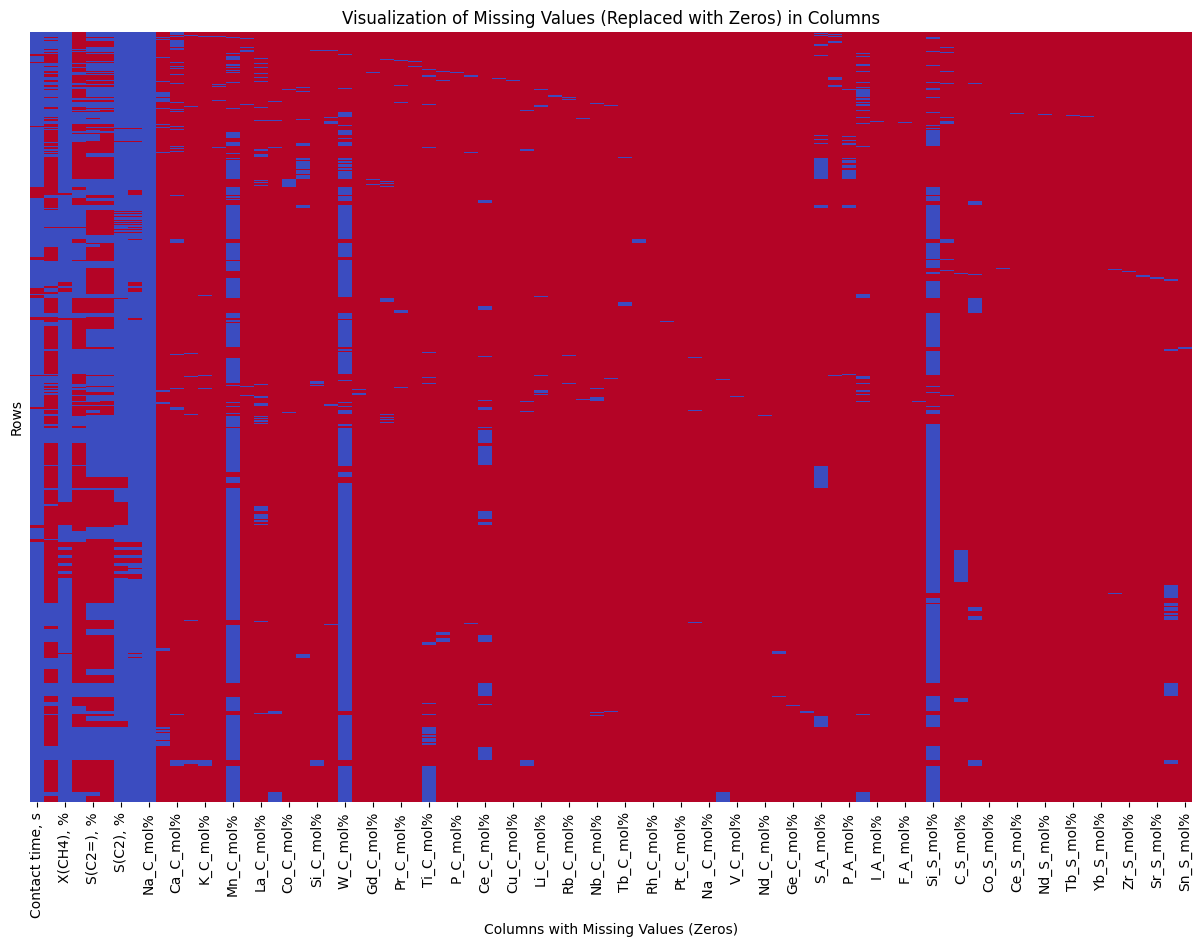

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_value_columns = Na.columns[Na.eq(0).any()].tolist()

# Creating a DataFrame to visualize the presence of zeros in these columns
visualization_df = Na[missing_value_columns].eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Columns")
plt.xlabel("Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

In [4]:
non_missing_value_columns = Na.columns[~Na.eq(0).any()].tolist()

non_missing_value_columns

['Promotor', 'Preparation', 'Temperature, K', 'p(CH4)/p(O2)', 'p total, bar']

In [5]:
Na = Na[Na['Na_C_mol%'] != 0]

In [6]:
# Finding the row indices where 'Na_C_mol%' column has missing values (replaced with zeros)
missing_value_indices = Na.index[Na['Na_C_mol%'] == 0].tolist()

missing_value_indices

[]

In [7]:
non_missing_value_columns = Na.columns[~Na.eq(0).any()].tolist()

non_missing_value_columns

['Promotor',
 'Preparation',
 'Temperature, K',
 'p(CH4)/p(O2)',
 'p total, bar',
 'Na_C_mol%']

In [8]:
print("Data type of 'Preparation':", Na['Preparation'].dtype)
print("Unique values in 'Preparation':", Na['Preparation'].unique())
print("Data type of 'Promotor':", Na['Promotor'].dtype)
print("Unique values in 'Promotor':", Na['Promotor'].unique())

Data type of 'Preparation': object
Unique values in 'Preparation': ['Impregnation' 'n.a.' 'Therm.decomp.' 'Precipitation' 'Pyrolysis'
 'Sol-gel' 'Citric acid method' 'Slurry' 'Solid-phase technique'
 'Physical mixing' 'IJP-A synthesis' 'SCS' 'Pechini method']
Data type of 'Promotor': object
Unique values in 'Promotor': ['0' 'Cl' 'P' 'B' 'Cl_B']


In [9]:
# One-hot encoding the 'Preparation' column based on the condition
# If 'Preparation' is 'n.a.', encode as 0, otherwise as 1
Na['Preparation'] = Na['Preparation'].apply(lambda x: 0 if x == 'n.a.' else 1)
Na['Promotor'] = Na['Promotor'].apply(lambda x: 0 if x == '0' else 1)

# Show the first few rows of the dataframe to confirm the changes
Na[['Preparation', 'Preparation']].head()
Na[['Promotor', 'Promotor']].head()

Na.head()

print("Data type of 'Preparation':", Na['Promotor'].dtype)
print("Unique values in 'Preparation':", Na['Promotor'].unique())

Data type of 'Preparation': int64
Unique values in 'Preparation': [0 1]


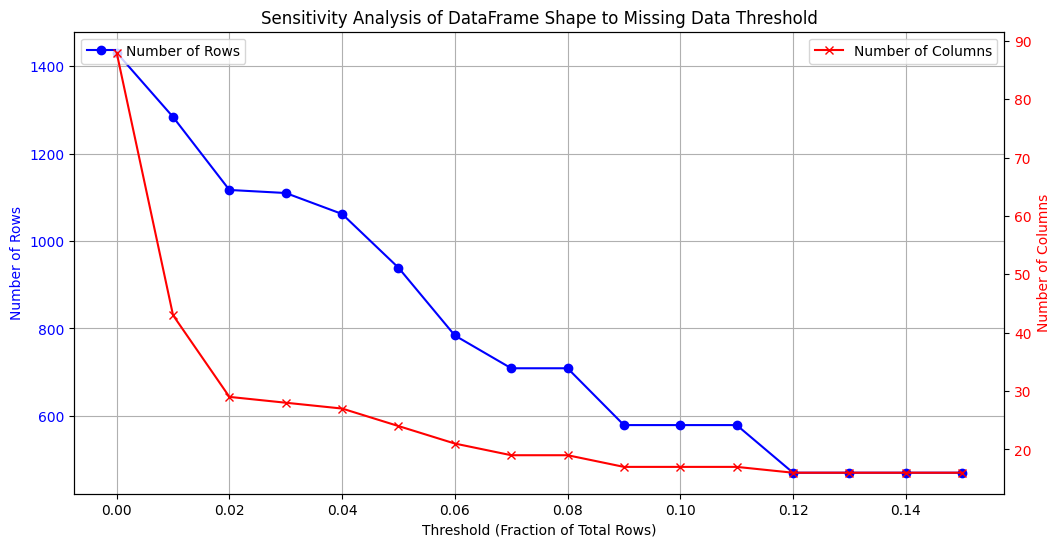

In [10]:
# Calculate the total number of rows in the DataFrame
total_rows = len(Na)

# Initialize lists to store results of shape (number of rows, number of columns) for each threshold
thresholds = []
num_rows_list = []
num_columns_list = []

# Perform sensitivity analysis for thresholds from 0% to 15%
for threshold in range(0, 16):
    threshold /= 100  # Convert to fraction
    thresholds.append(threshold)
    
    # Identify columns where non-zero (non-missing) data is less than the given threshold of total rows
    columns_to_remove = []
    rows_to_remove = set()

    for col in Na.columns:
        non_zero_count = len(Na[Na[col] != 0])
        if non_zero_count / total_rows < threshold:
            columns_to_remove.append(col)
            # Collect row indices where data in this column is not missing (not zero)
            rows_to_remove.update(Na.index[Na[col] != 0].tolist())

    # Remove the identified columns and rows
    temp_df = Na.drop(columns=columns_to_remove)
    temp_df.drop(index=list(rows_to_remove), inplace=True)
    
    # Store the shape of the DataFrame after filtering and pruning
    num_rows, num_columns = temp_df.shape
    num_rows_list.append(num_rows)
    num_columns_list.append(num_columns)

# Create a plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot for Number of Rows on the left y-axis
ax1.plot(thresholds, num_rows_list, label='Number of Rows', marker='o', color='b')
ax1.set_xlabel('Threshold (Fraction of Total Rows)')
ax1.set_ylabel('Number of Rows', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax1.grid(True)

# Create a second y-axis to plot Number of Columns
ax2 = ax1.twinx()
ax2.plot(thresholds, num_columns_list, label='Number of Columns', marker='x', color='r')
ax2.set_ylabel('Number of Columns', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')

# Title for the plot
plt.title('Sensitivity Analysis of DataFrame Shape to Missing Data Threshold')

plt.show()

In [11]:
# Identify columns where non-zero (non-missing) data is less than 2% of total rows
columns_to_remove = []
rows_to_remove = set()

for col in Na.columns:
    if col != 'Promotor':  # Skip the 'Promotor' column
        non_zero_count = len(Na[Na[col] != 0])
        if non_zero_count / total_rows < 0.02:
            columns_to_remove.append(col)
            # Collect row indices where data in this column is not missing (not zero)
            rows_to_remove.update(Na.index[Na[col] != 0].tolist())

# Remove the identified columns and rows
filtered_Na = Na.drop(columns=columns_to_remove)
filtered_Na.drop(index=list(rows_to_remove), inplace=True)

filtered_Na.shape

(1125, 30)

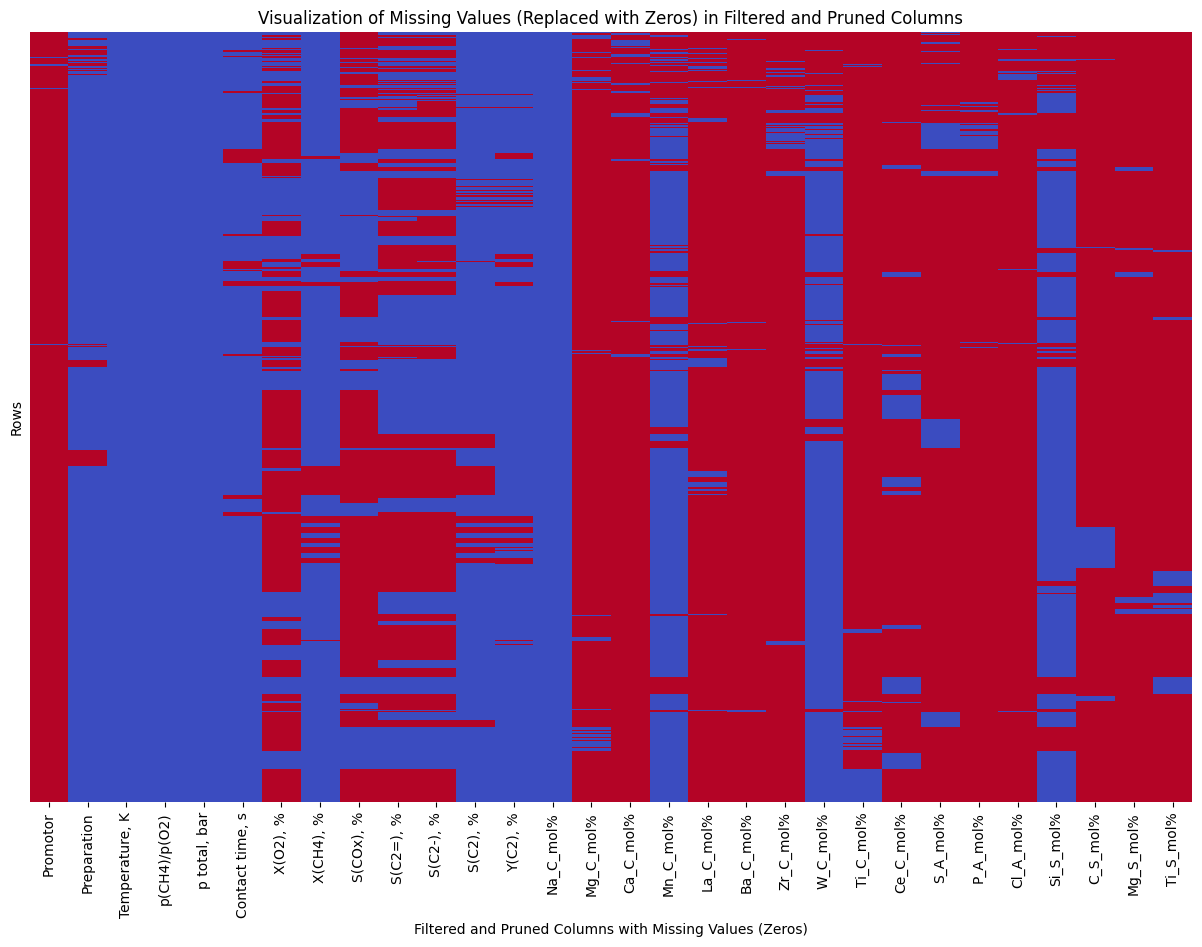

In [12]:
visualization_pruned_df = filtered_Na.eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_pruned_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Filtered and Pruned Columns")
plt.xlabel("Filtered and Pruned Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

In [13]:
# Calculate 'Y(C2), %' where it's missing (NaN or 0) using 'S(C2), %' and 'X(CH4), %'
filtered_Na.loc[filtered_Na['Y(C2), %'] == 0, 'Y(C2), %'] = \
    filtered_Na['S(C2), %'] * filtered_Na['X(CH4), %']/100

# Remove rows where 'Y(C2), %' has missing values (reduced to zeros)
filtered_Na = filtered_Na[filtered_Na['Y(C2), %'] != 0]
filtered_Na = filtered_Na[filtered_Na['Contact time, s'] != 0]

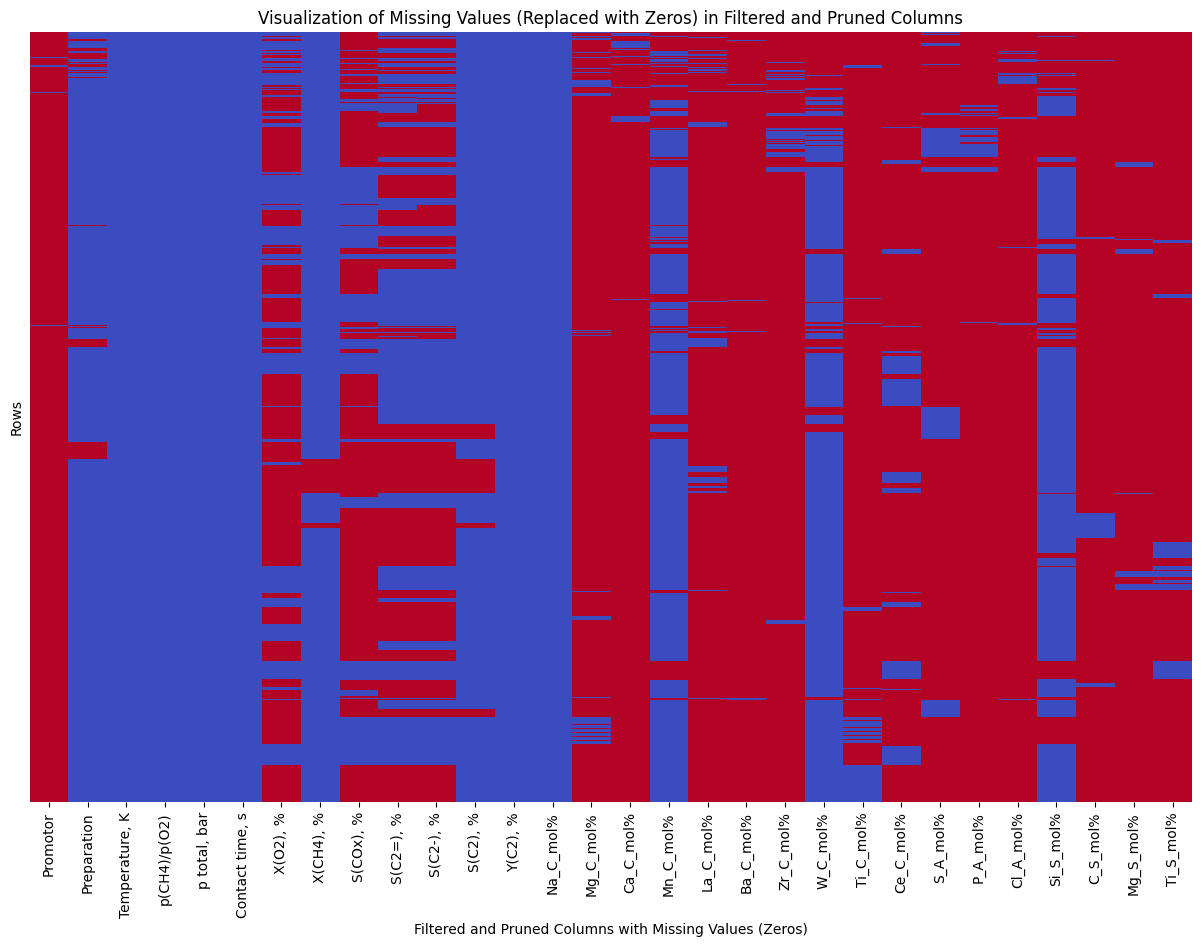

In [14]:
visualization_pruned_df = filtered_Na.eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_pruned_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Filtered and Pruned Columns")
plt.xlabel("Filtered and Pruned Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


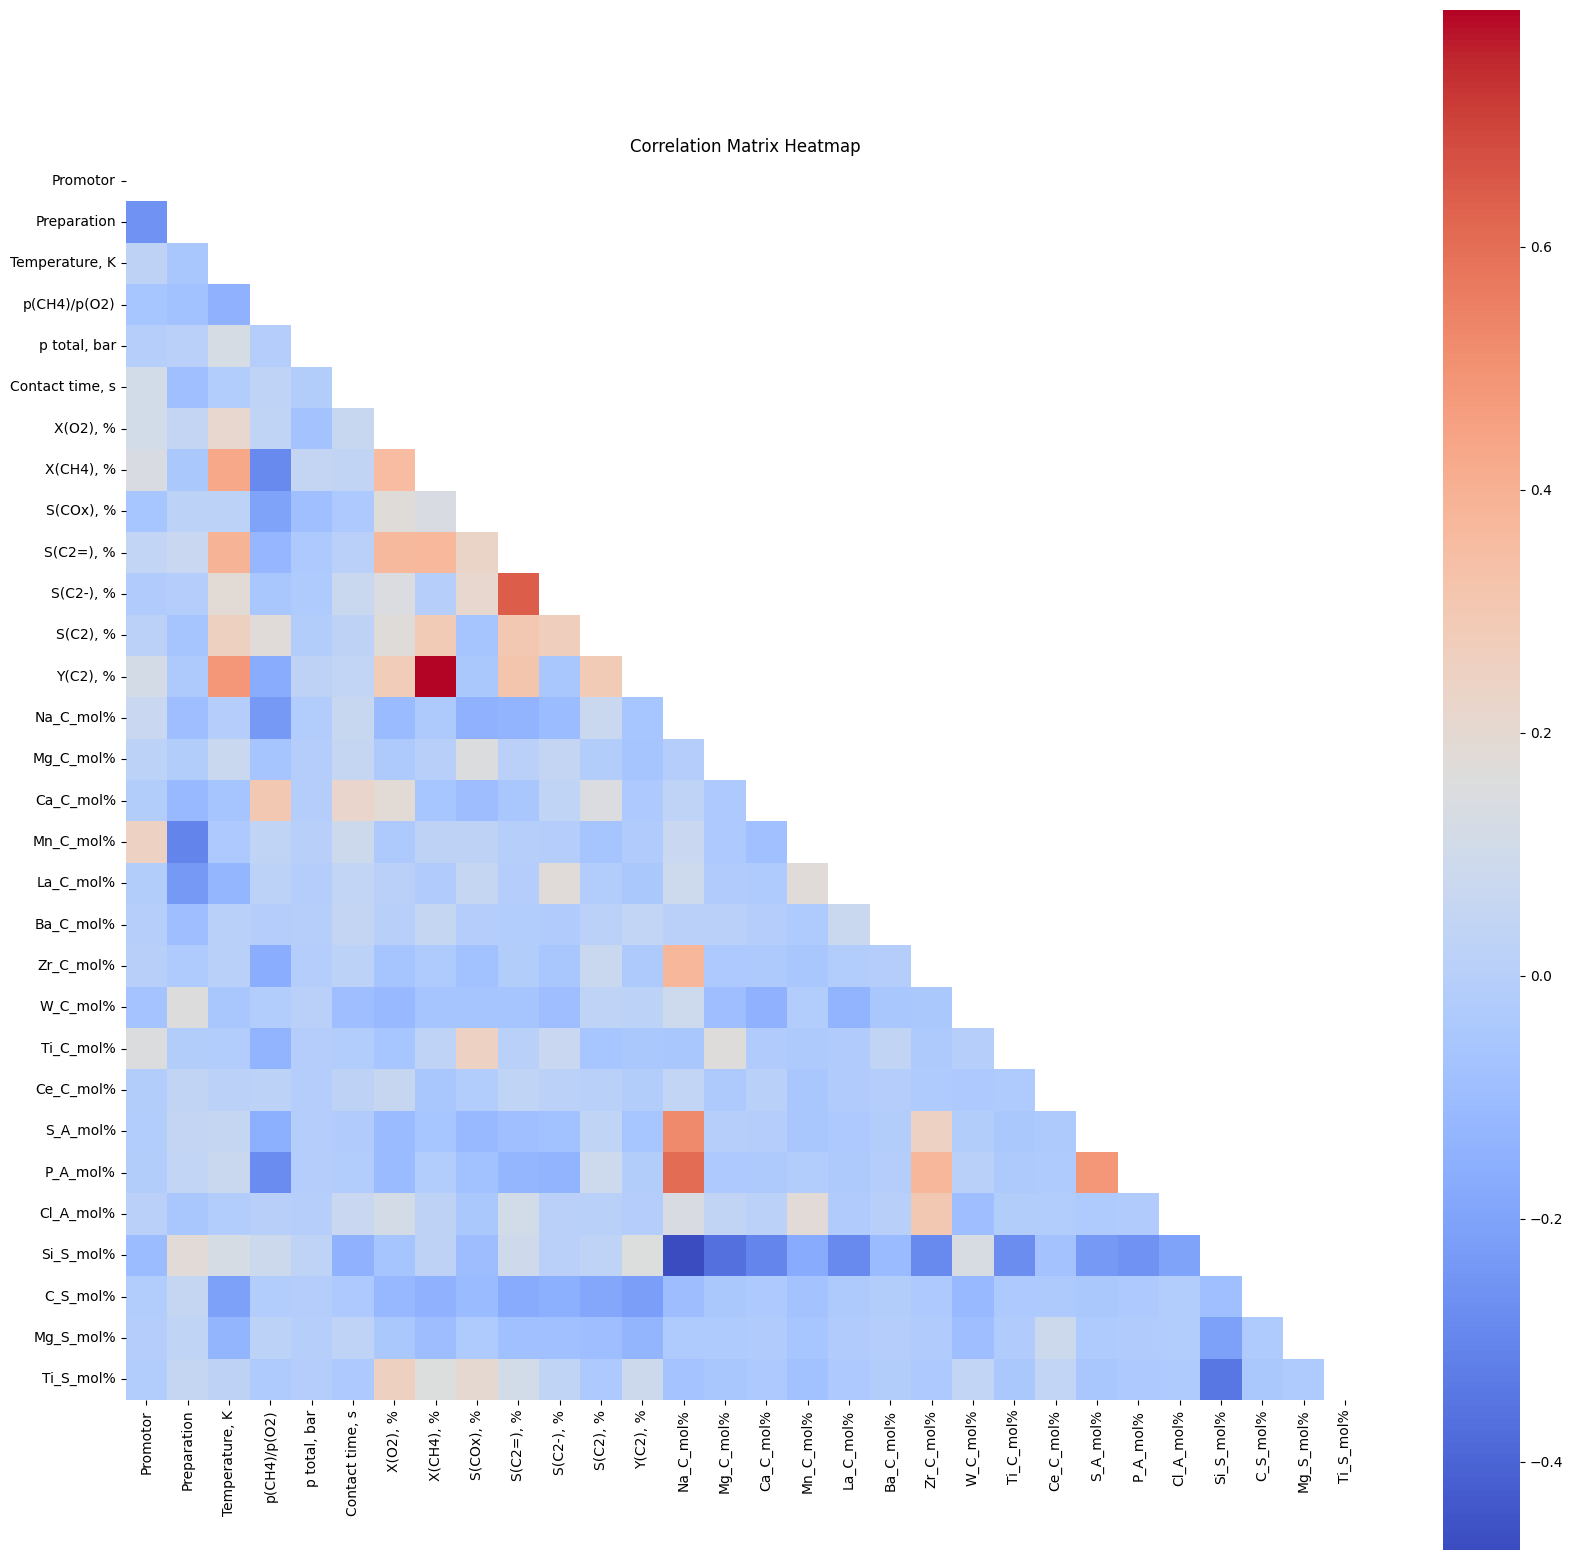

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = filtered_Na.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 20))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, mask=mask)

# Add title
plt.title('Correlation Matrix Heatmap')

plt.show()

In [16]:
# Find pairs of features with high absolute correlation
threshold = 0.6  # You can change the threshold value as needed
high_correlation_pairs = {}

# Iterate over the correlation matrix to find high correlation pairs
for column in correlation_matrix.columns:
    for index in correlation_matrix.index:
        if index == column:
            continue  # Skip the diagonal elements
        correlation_value = correlation_matrix.loc[index, column]
        if abs(correlation_value) > threshold:
            pair = f"{index} and {column}"
            high_correlation_pairs[pair] = correlation_value

high_correlation_pairs

{'Y(C2), % and X(CH4), %': 0.7949231181259191,
 'S(C2-), % and S(C2=), %': 0.6427230708121329,
 'S(C2=), % and S(C2-), %': 0.6427230708121329,
 'X(CH4), % and Y(C2), %': 0.7949231181259191,
 'P_A_mol% and Na_C_mol%': 0.603195581937961,
 'Na_C_mol% and P_A_mol%': 0.603195581937961}

EDA (Exploratory data analysis)

         Promotor  Preparation  Temperature, K  p(CH4)/p(O2)  p total, bar  \
count  994.000000   994.000000      994.000000    994.000000    994.000000   
mean     0.008048     0.938632     1048.336016      4.025855      1.025755   
std      0.089395     0.240125       60.664595      2.193717      0.556659   
min      0.000000     0.000000      723.000000      0.300000      0.200000   
25%      0.000000     1.000000     1013.000000      3.000000      1.000000   
50%      0.000000     1.000000     1069.000000      4.000000      1.000000   
75%      0.000000     1.000000     1073.000000      5.000000      1.000000   
max      1.000000     1.000000     1198.000000     21.000000     10.000000   

       Contact time, s    X(O2), %   X(CH4), %   S(COx), %   S(C2=), %  ...  \
count       994.000000  994.000000  994.000000  994.000000  994.000000  ...   
mean          0.358622   25.757847   20.022736   15.455332   15.700000  ...   
std           1.385861   40.703442   12.756957   23.713712  

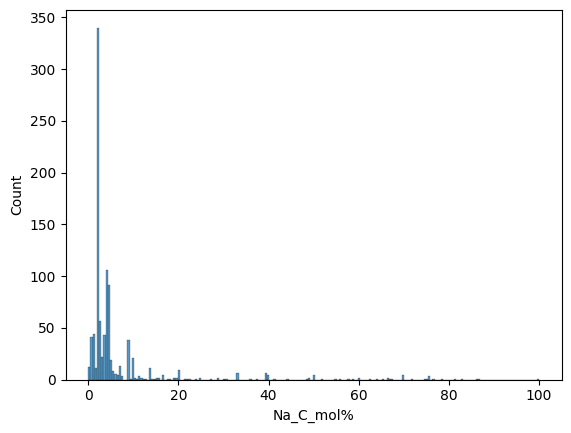

In [17]:
# 기초 통계량 확인
print(filtered_Na.describe())

# 결측치 확인
print(filtered_Na.isnull().sum())

# 히스토그램
sns.histplot(filtered_Na['Na_C_mol%'])
plt.show()

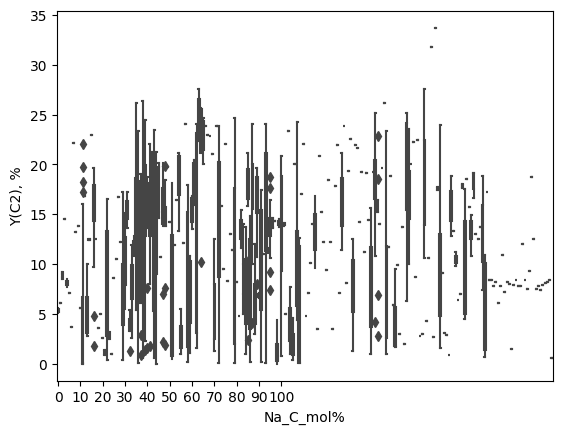

In [18]:
sns.boxplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na)
# X 축 눈금 설정: 0부터 100까지 10단위
plt.xticks(ticks=range(0, 101, 10), labels=[str(i) for i in range(0, 101, 10)])

plt.show()

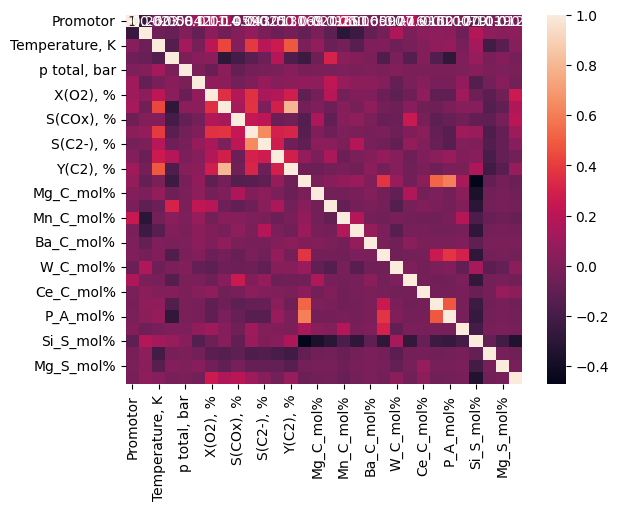

In [19]:
# 상관 관계 분석
correlation_matrix = filtered_Na.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [20]:
# Z-score를 이용한 이상치 탐지
from scipy import stats
import numpy as np

# Resetting the index
filtered_Na.reset_index(drop=True, inplace=True)

# Now calculate the z-scores
z_scores = np.abs(stats.zscore(filtered_Na['Y(C2), %']))
outliers_values_z_score = filtered_Na['Y(C2), %'][np.where(z_scores > 3)[0]]

print("Outliers values detected via Z-score:", outliers_values_z_score)

Outliers values detected via Z-score: 278    33.7
Name: Y(C2), %, dtype: float64


In [21]:
Q1 = filtered_Na['Y(C2), %'].quantile(0.25)
Q3 = filtered_Na['Y(C2), %'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = filtered_Na[(filtered_Na['Y(C2), %'] < (Q1 - 1.5 * IQR)) | (filtered_Na['Y(C2), %'] > (Q3 + 1.5 * IQR))].index
outliers_values_iqr = filtered_Na['Y(C2), %'][outliers_iqr]

print("Outliers values detected via IQR:", outliers_values_iqr)

Outliers values detected via IQR: Series([], Name: Y(C2), %, dtype: float64)


In [22]:
# Z-score 기반 이상치 제거
filtered_Na = filtered_Na[(z_scores <= 3)]

# IQR 기반 이상치 제거
filtered_Na = filtered_Na[~filtered_Na.index.isin(outliers_iqr)]

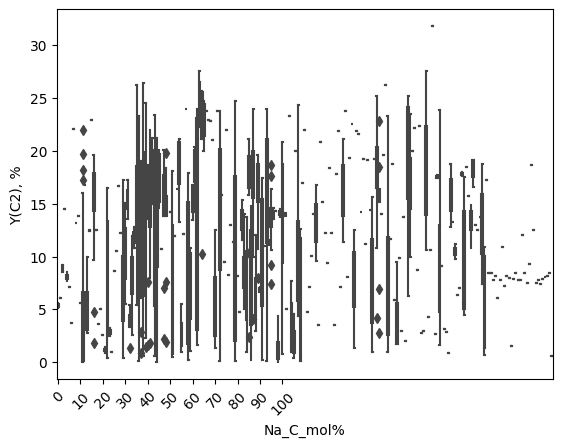

<Figure size 1000x600 with 0 Axes>

In [23]:
# Boxplot 생성
sns.boxplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na)

# X 축 눈금 설정: 0부터 100까지 10단위
plt.xticks(ticks=range(0, 101, 10), labels=[str(i) for i in range(0, 101, 10)])
plt.xticks(rotation=45)
plt.figure(figsize=(10, 6))

plt.draw()

<Axes: >

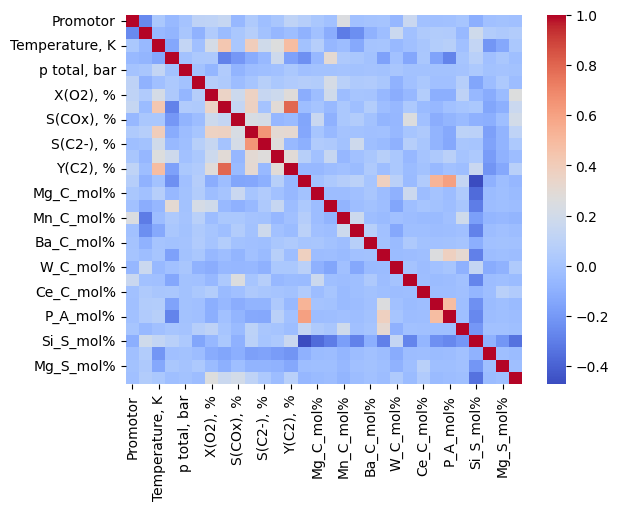

In [24]:
sns.heatmap(filtered_Na.corr(), cmap='coolwarm')

In [25]:
main_Na = filtered_Na.drop(['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %'], axis=1)

main_Na.head()

,Promotor,Preparation,"Temperature, K",p(CH4)/p(O2),"p total, bar","Contact time, s","S(COx), %",Na_C_mol%,Mg_C_mol%,Ca_C_mol%,...,W_C_mol%,Ti_C_mol%,Ce_C_mol%,S_A_mol%,P_A_mol%,Cl_A_mol%,Si_S_mol%,C_S_mol%,Mg_S_mol%,Ti_S_mol%
0,0,1,1017,8.0,1.0,0.19,0.0,7.0,33.0,0.0,...,0.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1021,8.0,1.0,0.16,0.0,5.5,0.0,94.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,1023,8.1,1.0,38.40,0.0,7.0,0.0,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,1018,8.1,1.0,0.25,0.0,3.6,0.0,94.6,...,0.0,0.0,0.0,1.8,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,1026,8.0,1.0,0.47,0.0,7.0,0.0,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

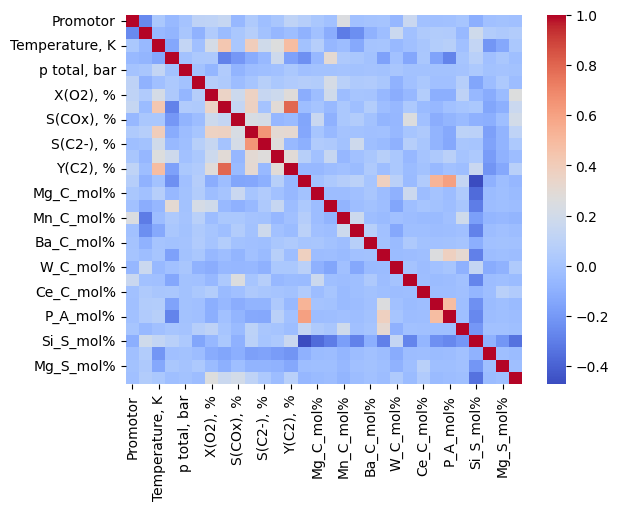

In [26]:
sns.heatmap(data=filtered_Na.corr(), cmap='coolwarm')

In [27]:
# Calculate the correlation matrix
correlation_matrix_Na = main_Na.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix_Na, dtype=bool))

# Find pairs of features with high absolute correlation
threshold = 0.4  # You can change the threshold value as needed
high_correlation_pairs = {}

# Iterate over the correlation matrix to find high correlation pairs
for column in correlation_matrix_Na.columns:
    for index in correlation_matrix_Na.index:
        if index == column:
            continue  # Skip the diagonal elements
        correlation_value = correlation_matrix_Na.loc[index, column]
        if abs(correlation_value) > threshold:
            pair = f"{index} and {column}"
            high_correlation_pairs[pair] = correlation_value

high_correlation_pairs

{'S_A_mol% and Na_C_mol%': 0.5250664503991607,
 'P_A_mol% and Na_C_mol%': 0.60360759085708,
 'Si_S_mol% and Na_C_mol%': -0.47269853022607433,
 'Na_C_mol% and S_A_mol%': 0.5250664503991607,
 'P_A_mol% and S_A_mol%': 0.4837233898989661,
 'Na_C_mol% and P_A_mol%': 0.60360759085708,
 'S_A_mol% and P_A_mol%': 0.4837233898989661,
 'Na_C_mol% and Si_S_mol%': -0.47269853022607433}

<Axes: xlabel='Na_C_mol%', ylabel='Count'>

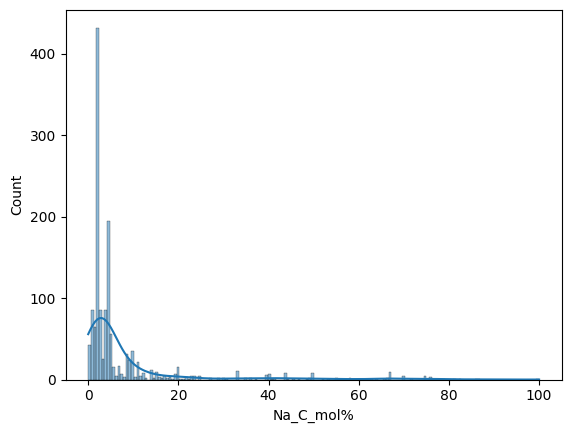

In [28]:
sns.histplot(data=Na, x='Na_C_mol%', kde=True)

<Axes: xlabel='Na_C_mol%', ylabel='Count'>

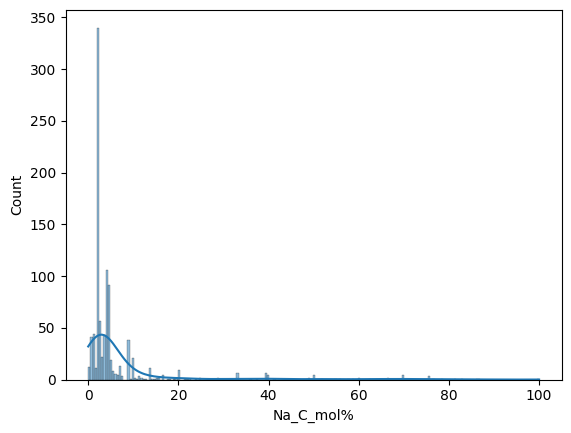

In [29]:
sns.histplot(data=filtered_Na, x='Na_C_mol%', kde=True)

<Axes: xlabel='Temperature, K', ylabel='Count'>

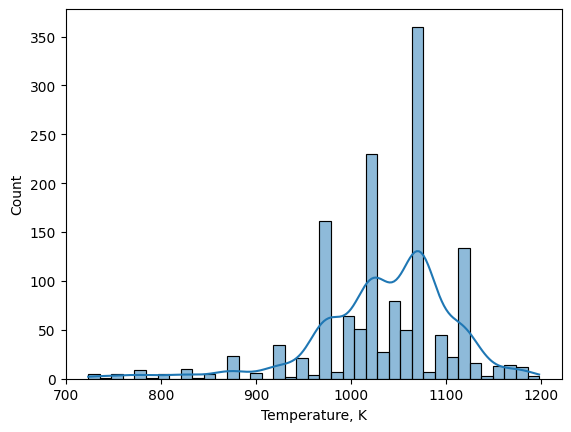

In [30]:
sns.histplot(data=Na, x='Temperature, K', kde=True)

<Axes: xlabel='Temperature, K', ylabel='Count'>

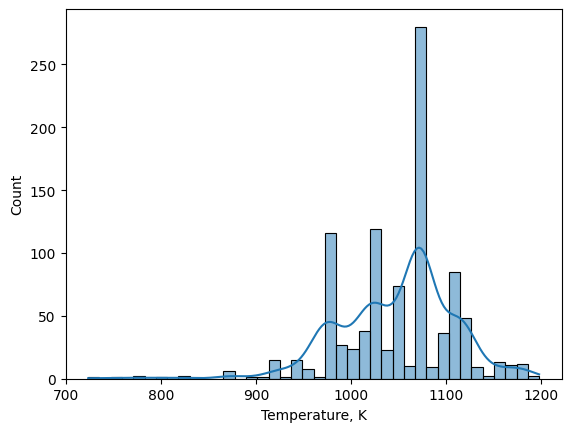

In [31]:
sns.histplot(data=filtered_Na, x='Temperature, K', kde=True)

<Axes: xlabel='p(CH4)/p(O2)', ylabel='Count'>

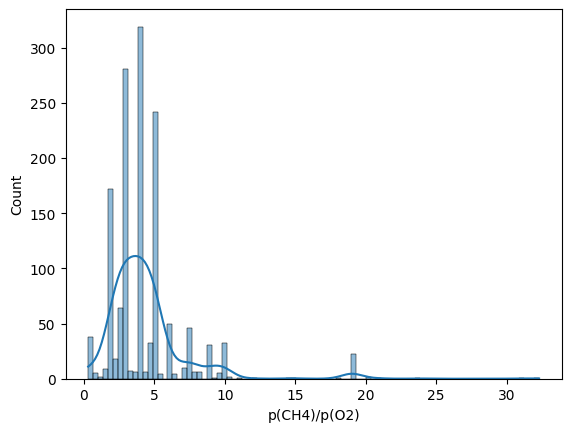

In [32]:
sns.histplot(data=Na, x='p(CH4)/p(O2)', kde=True)

<Axes: xlabel='p(CH4)/p(O2)', ylabel='Count'>

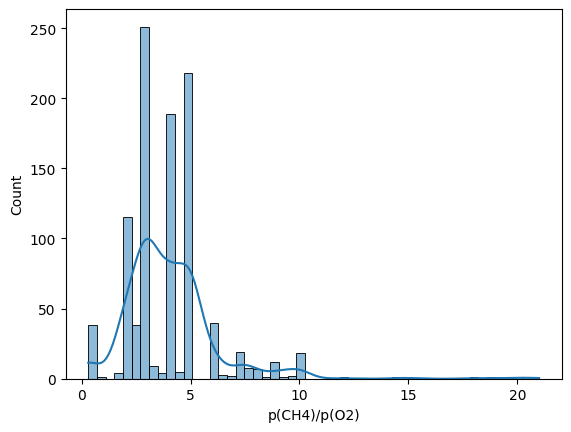

In [33]:
sns.histplot(data=filtered_Na, x='p(CH4)/p(O2)', kde=True)

<Axes: xlabel='p total, bar', ylabel='Count'>

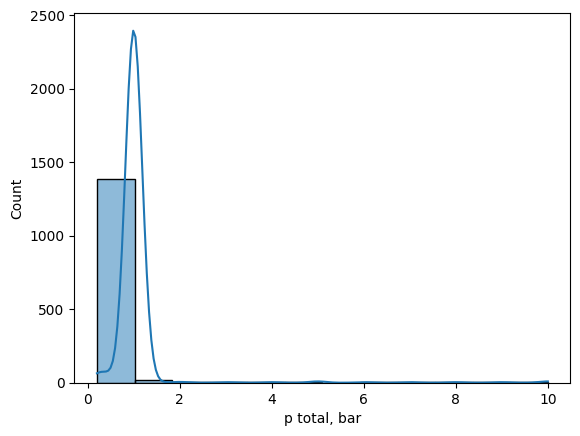

In [34]:
sns.histplot(data=Na, x='p total, bar', kde=True)

<Axes: xlabel='p total, bar', ylabel='Count'>

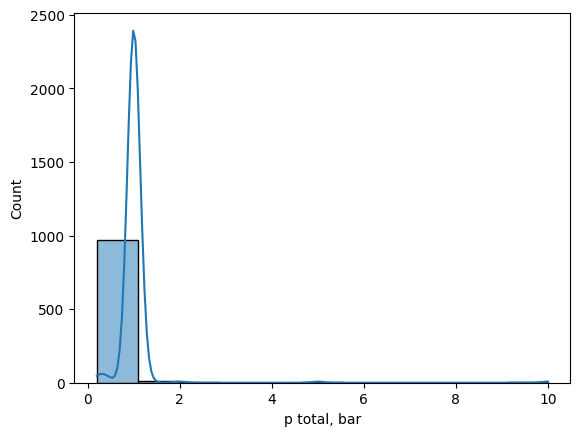

In [35]:
sns.histplot(data=filtered_Na, x='p total, bar', kde=True)

<Axes: xlabel='Contact time, s', ylabel='Count'>

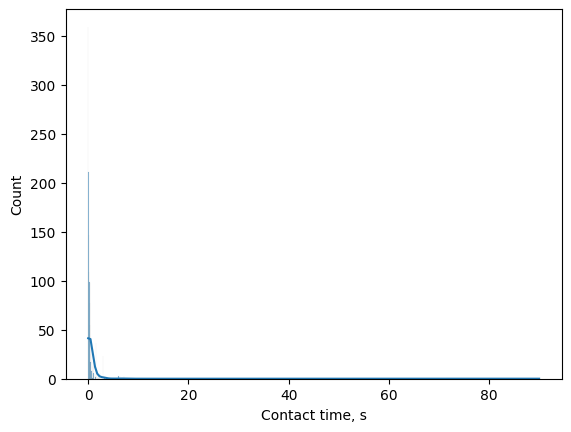

In [36]:
sns.histplot(data=Na, x='Contact time, s', kde=True)

<Axes: xlabel='Contact time, s', ylabel='Count'>

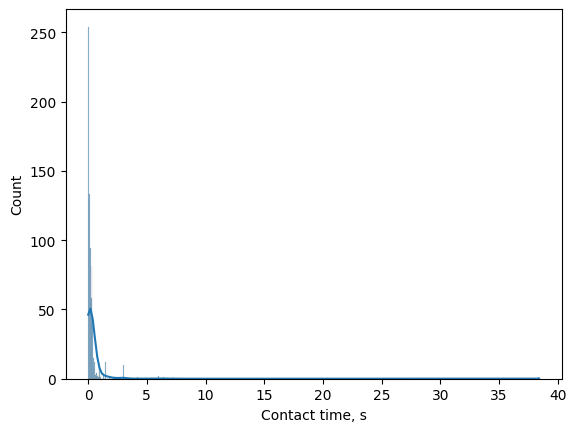

In [37]:
sns.histplot(data=filtered_Na, x='Contact time, s', kde=True)

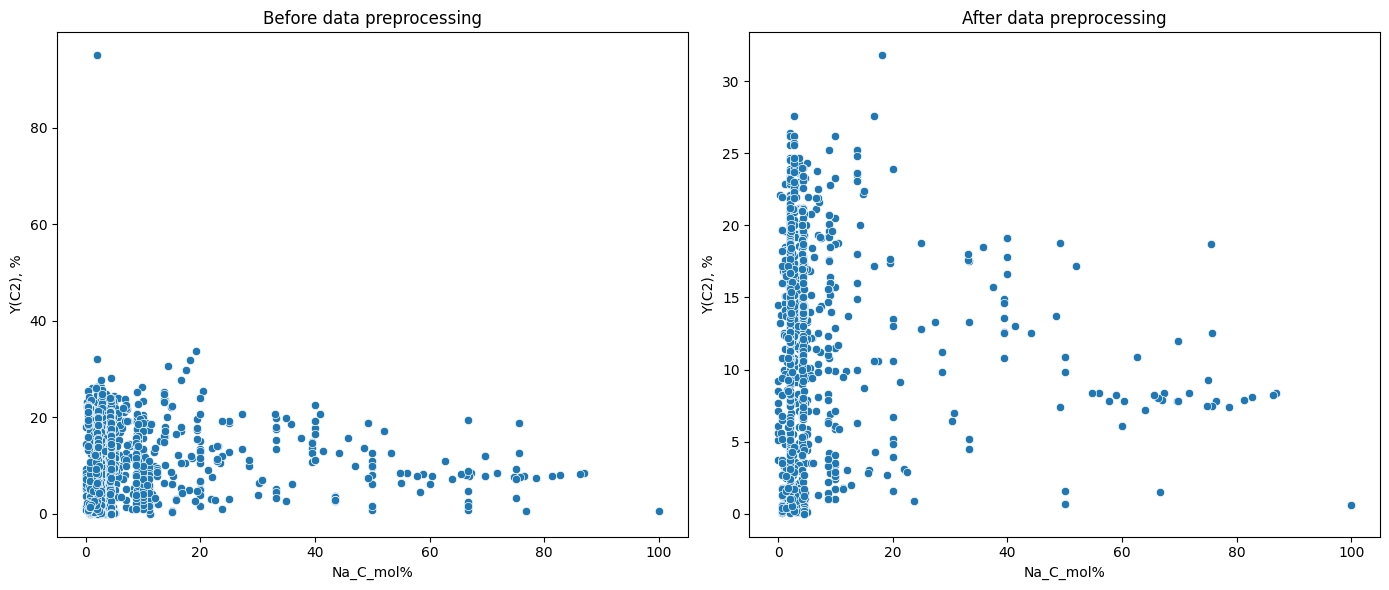

In [38]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

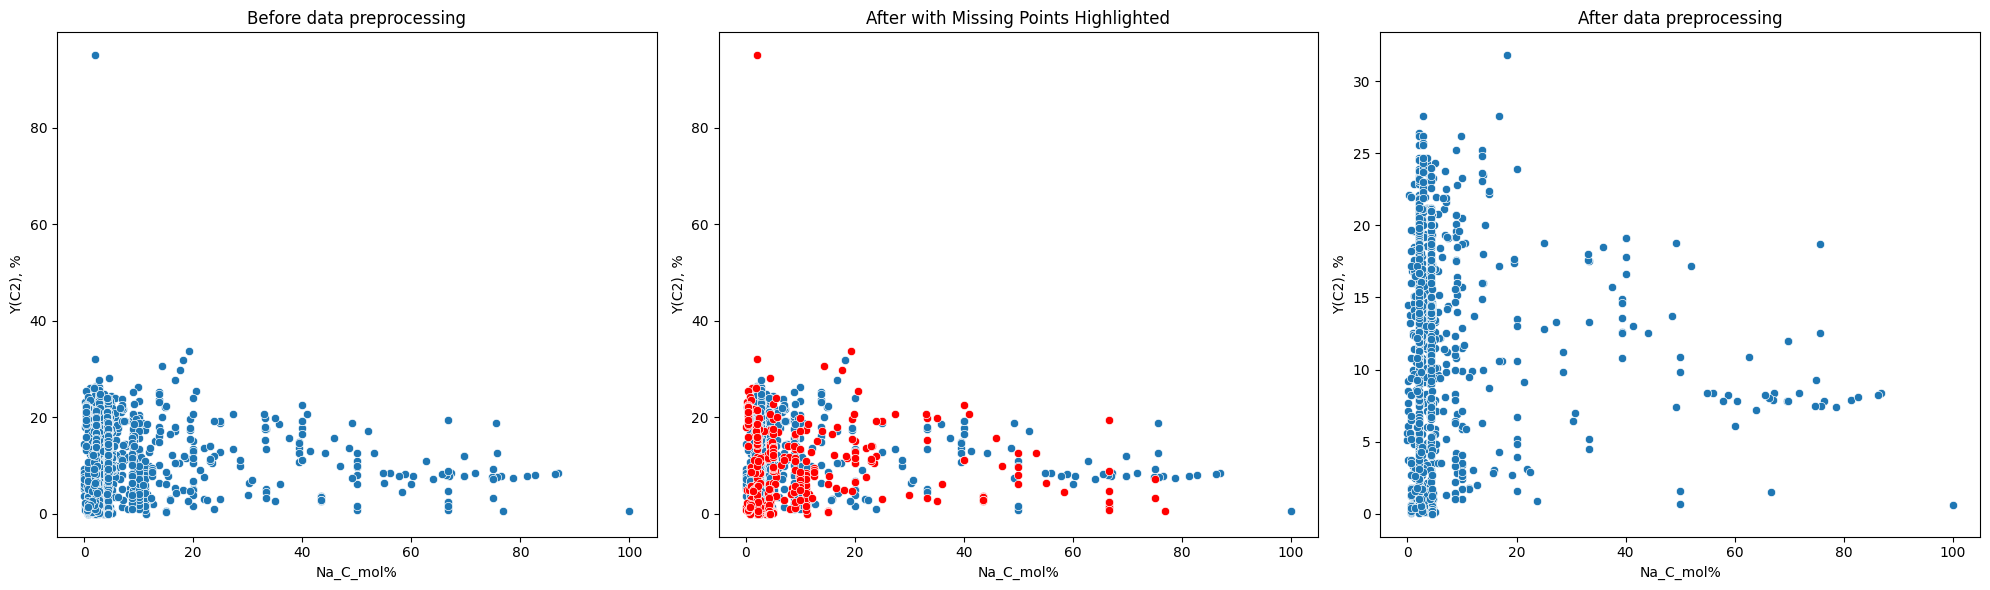

In [39]:
# Create a figure and a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Find points that are in 'Before' but not in 'After'
missing_points = pd.merge(Na, filtered_Na, on=['Na_C_mol%', 'Y(C2), %'], how='outer', indicator=True)
missing_points = missing_points[missing_points['_merge'] == 'left_only']

# Plot the scatterplot for "After with Missing Points Highlighted"
sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na, ax=axes[1])
if not missing_points.empty:
    sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=missing_points, ax=axes[1], color='red')
axes[1].set_title('After with Missing Points Highlighted')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na, ax=axes[2])
axes[2].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

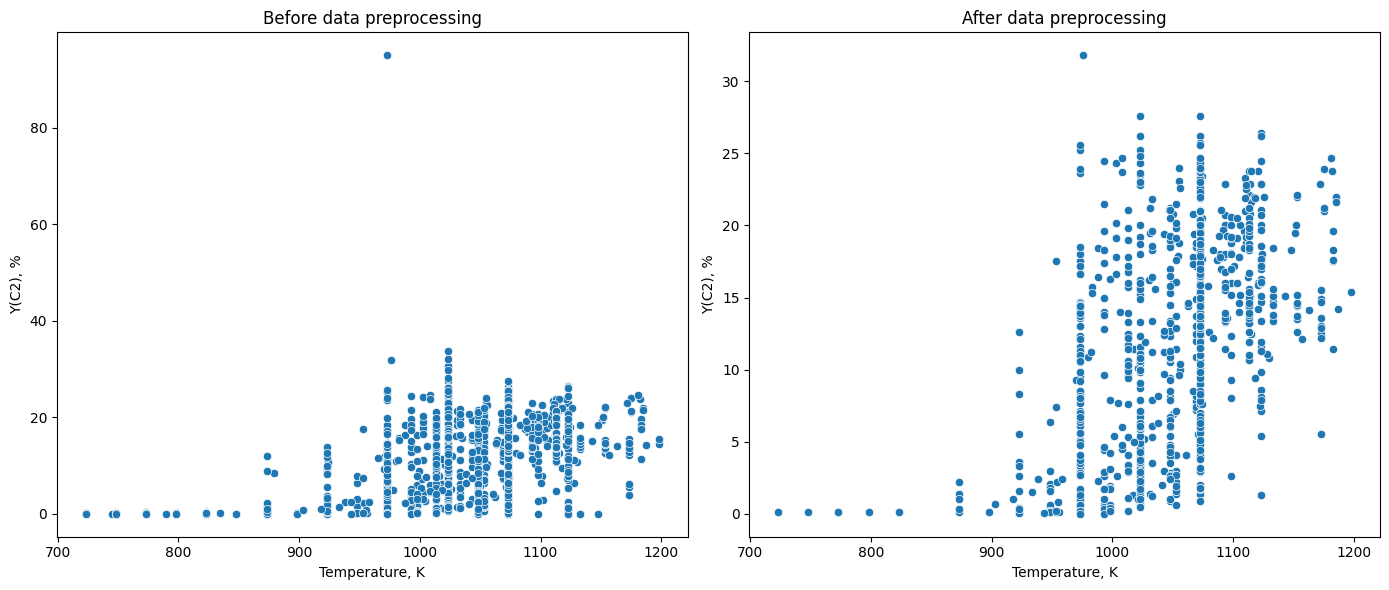

In [40]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Temperature, K', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Temperature, K', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

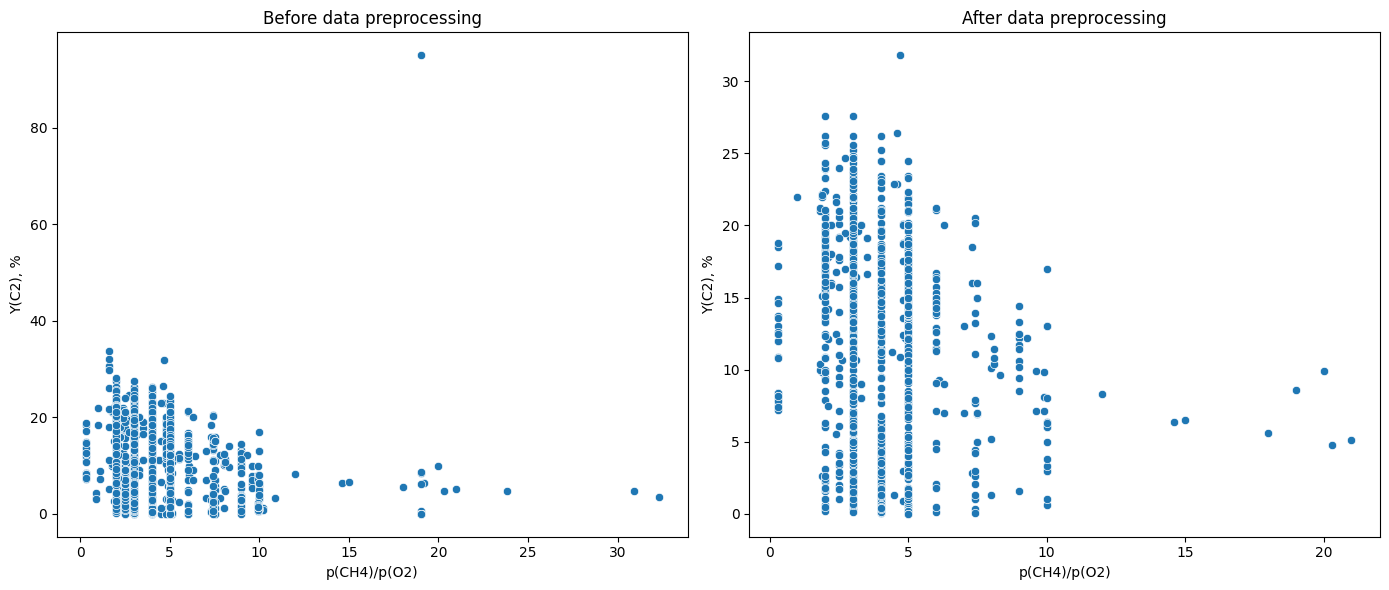

In [41]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='p(CH4)/p(O2)', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='p(CH4)/p(O2)', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

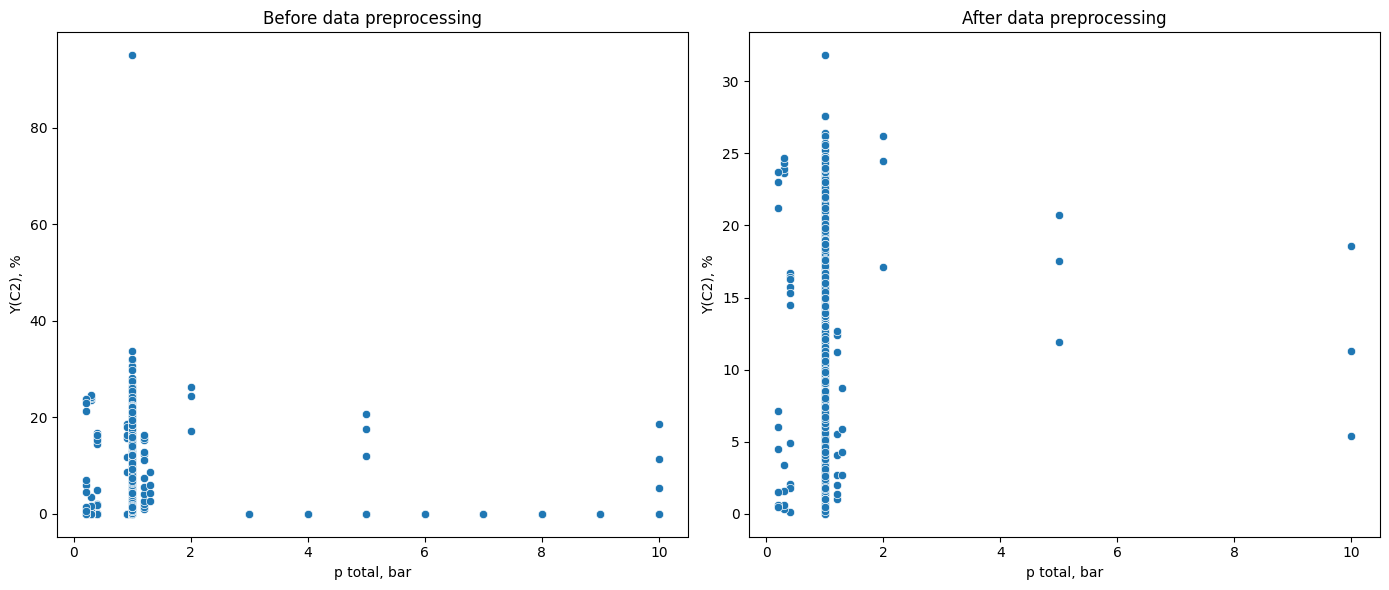

In [42]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='p total, bar', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='p total, bar', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

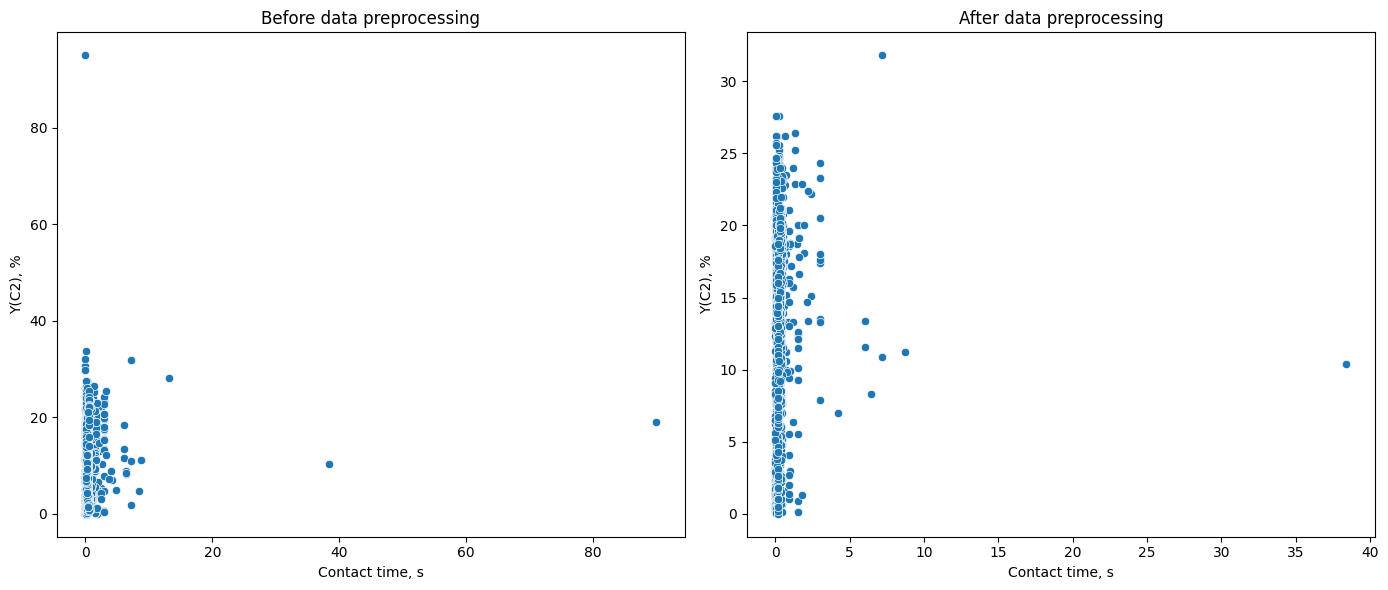

In [43]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Contact time, s', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Contact time, s', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

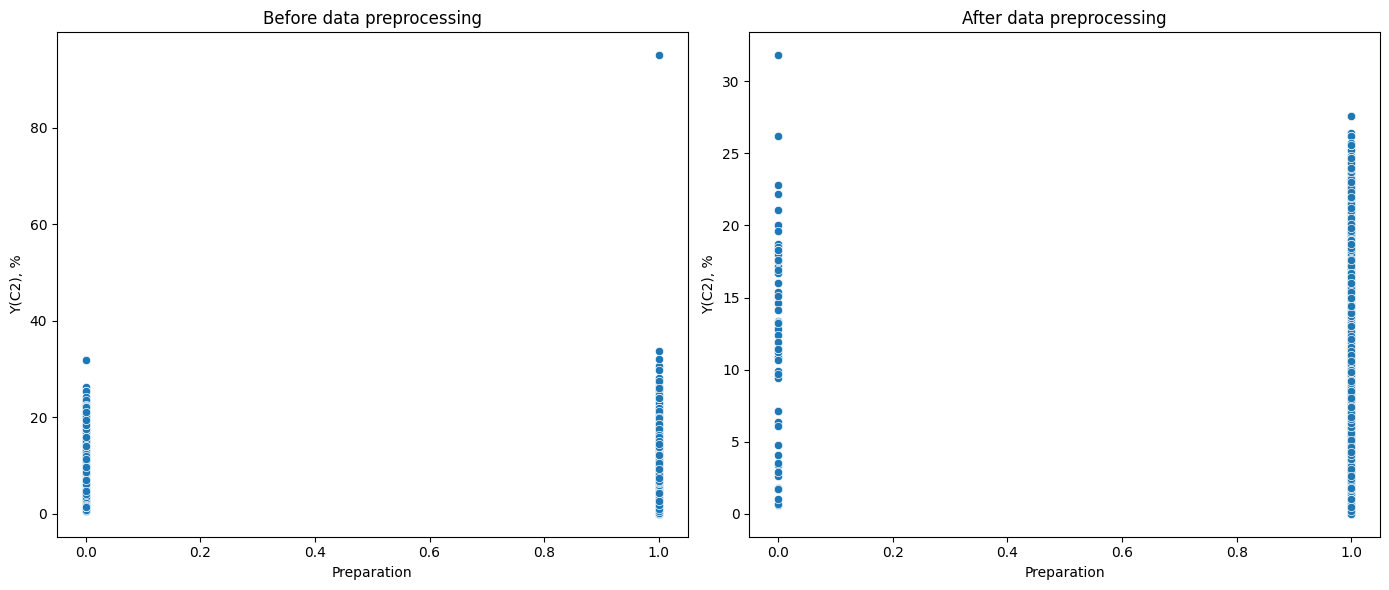

In [44]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Preparation', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Preparation', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

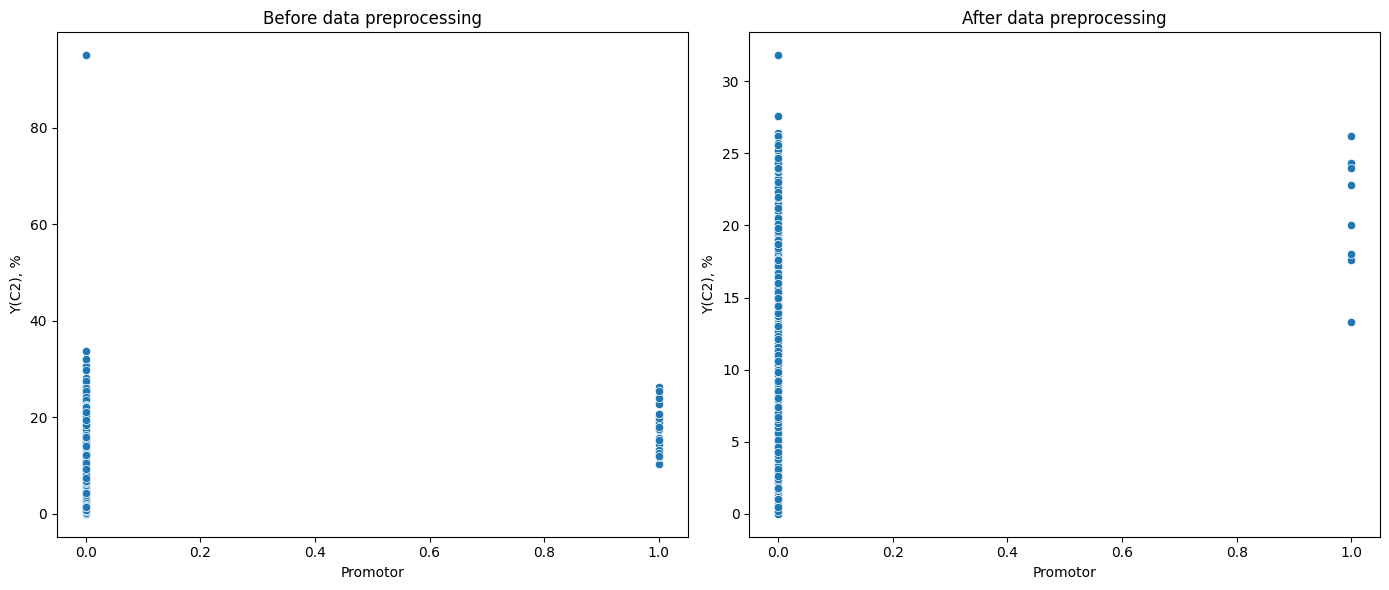

In [45]:
# Create a figure and a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the scatterplot for "Before data preprocessing"
sns.scatterplot(x='Promotor', y='Y(C2), %', data=Na, ax=axes[0])
axes[0].set_title('Before data preprocessing')

# Plot the scatterplot for "After data preprocessing"
sns.scatterplot(x='Promotor', y='Y(C2), %', data=filtered_Na, ax=axes[1])
axes[1].set_title('After data preprocessing')

# Show the plots
plt.tight_layout()
plt.show()

In [46]:
filtered_Na.shape

# 기초 통계량 확인
print(filtered_Na.describe())

         Promotor  Preparation  Temperature, K  p(CH4)/p(O2)  p total, bar  \
count  993.000000   993.000000      993.000000    993.000000    993.000000   
mean     0.008056     0.938570     1048.361531      4.028298      1.025780   
std      0.089440     0.240238       60.689828      2.193469      0.556939   
min      0.000000     0.000000      723.000000      0.300000      0.200000   
25%      0.000000     1.000000     1013.000000      3.000000      1.000000   
50%      0.000000     1.000000     1069.000000      4.000000      1.000000   
75%      0.000000     1.000000     1073.000000      5.000000      1.000000   
max      1.000000     1.000000     1198.000000     21.000000     10.000000   

       Contact time, s    X(O2), %   X(CH4), %   S(COx), %   S(C2=), %  ...  \
count       993.000000  993.000000  993.000000  993.000000  993.000000  ...   
mean          0.358963   25.702518   19.987513   15.433535   15.658610  ...   
std           1.386518   40.686536   12.714931   23.715697  

ML (Machine Learning)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import warnings
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

column_names = filtered_Na.columns.tolist()
column_names

input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
output_column = 'Y(C2), %'

input_columns

from sklearn.model_selection import train_test_split

X = filtered_Na[input_columns]
y = filtered_Na[output_column]

In [48]:
filtered_data = filtered_Na[(filtered_Na['Na_C_mol%'] >= 2.1) & (filtered_Na['Na_C_mol%'] <= 60)]

proportion_filtered = len(filtered_data) / len(filtered_Na['Na_C_mol%']) * 100

train_data = filtered_data
test_data = filtered_Na.drop(filtered_data.index)

print(f"Proportion of data where 'Na_C_mol%' is between 10 and 70: {proportion_filtered}%")
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of test_data: {test_data.shape}")

Proportion of data where 'Na_C_mol%' is between 10 and 70: 70.49345417925478%
Shape of train_data: (700, 30)
Shape of test_data: (293, 30)


In [49]:
# input_columns: The list of input features you want to consider for your model
input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]

# output_column: The output you are trying to predict
output_column = 'Y(C2), %'

# Define X_train, y_train based on the train_data DataFrame
X_train = train_data[input_columns]
y_train = train_data[output_column]

# Define X_test, y_test based on the test_data DataFrame
X_test = test_data[input_columns]
y_test = test_data[output_column]

C:\Users\OJH\AppData\Local\Temp\ipykernel_19244\3619130714.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(test_data[col], label='Test', color='r')


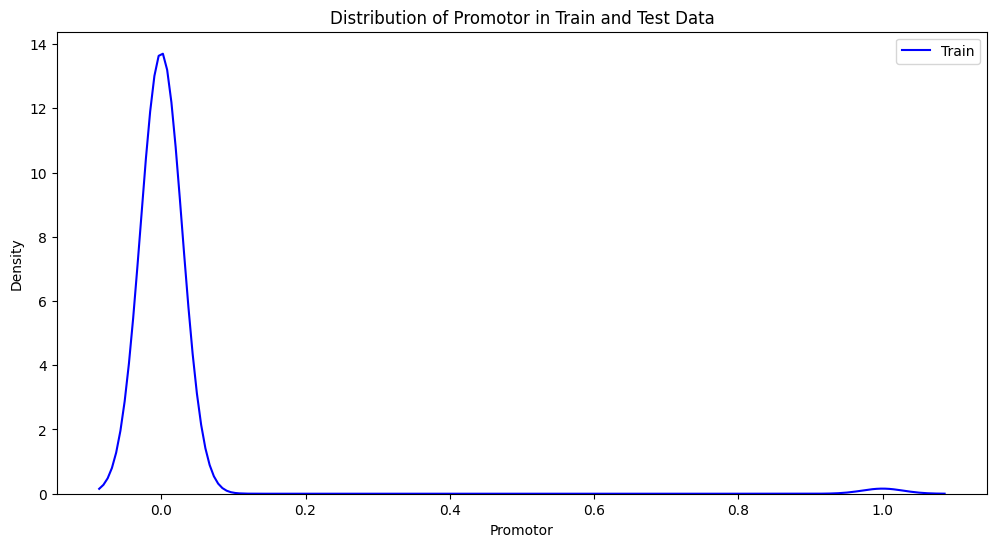

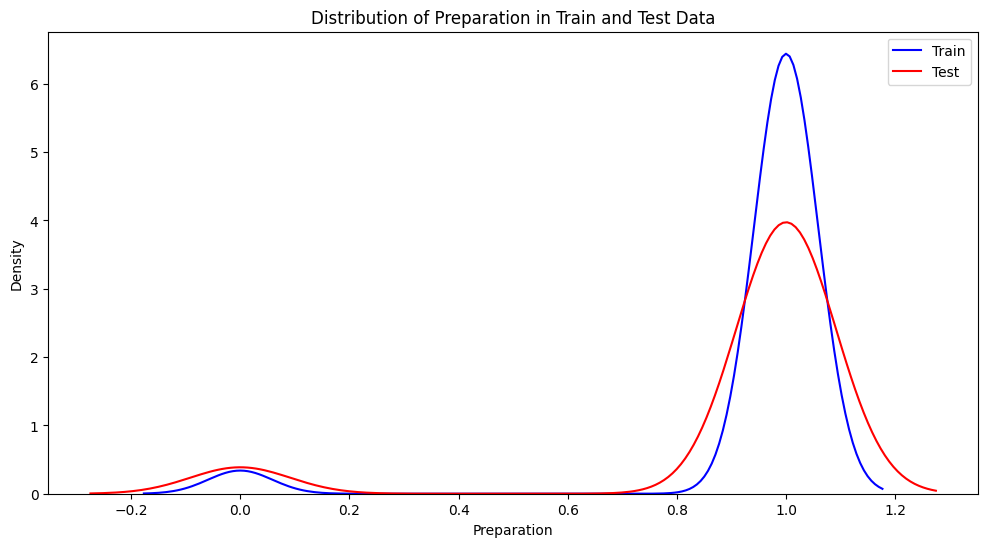

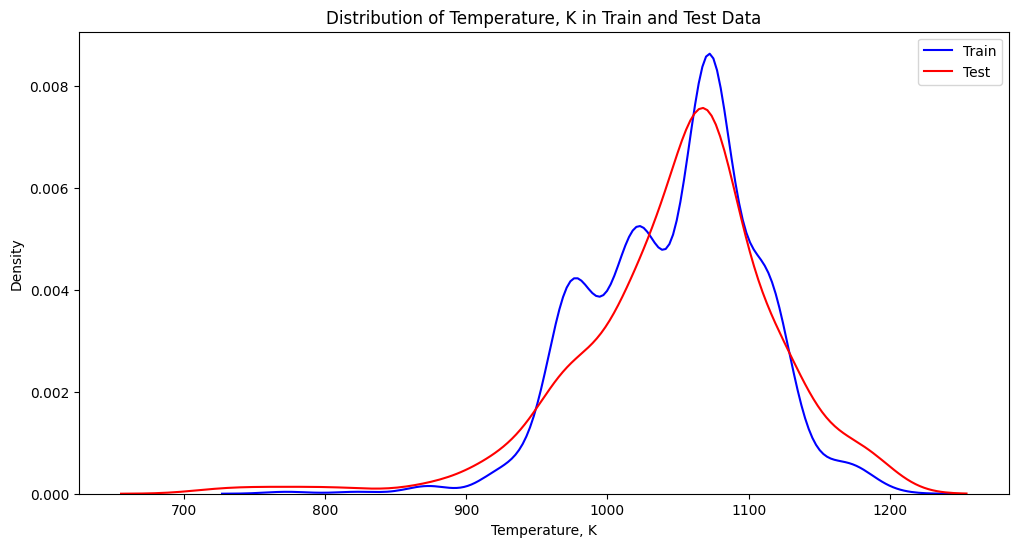

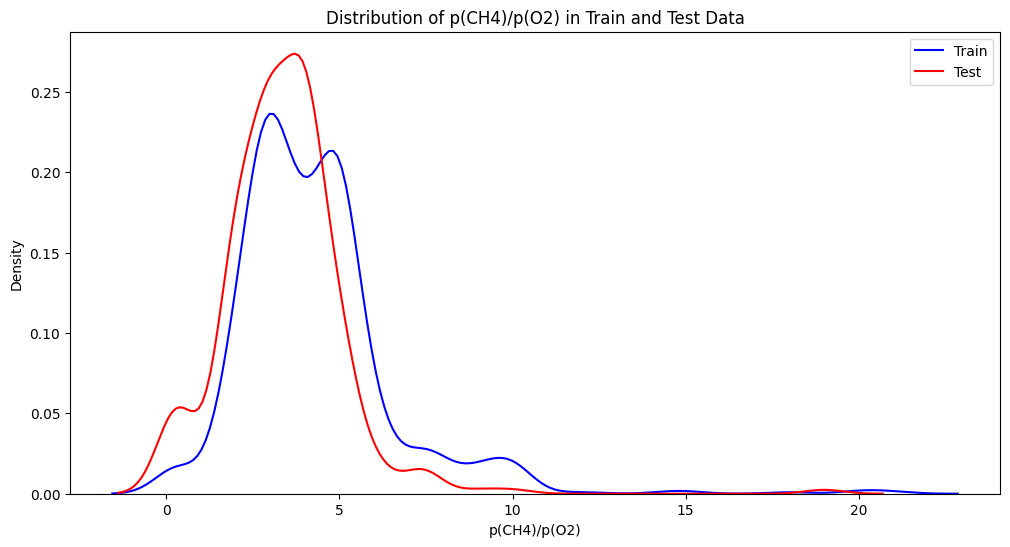

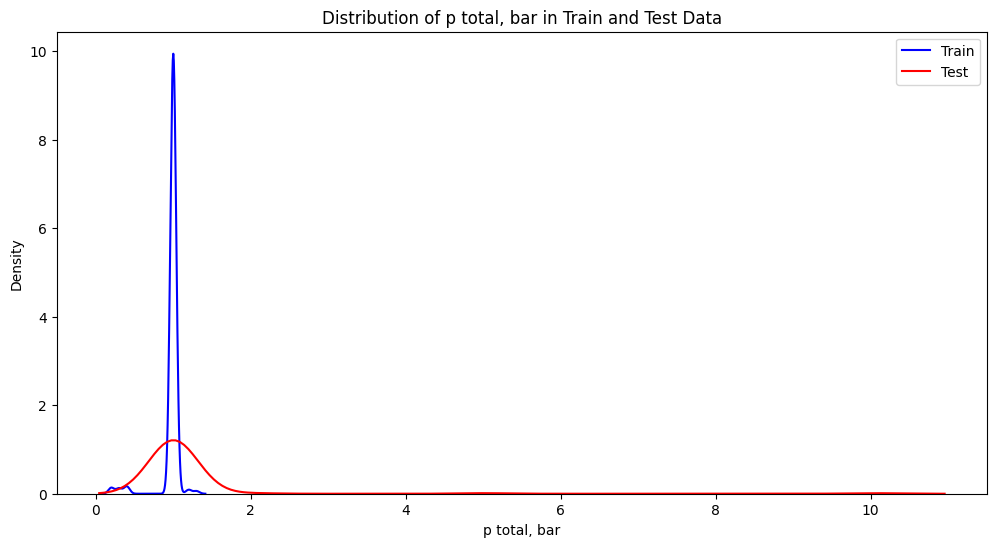

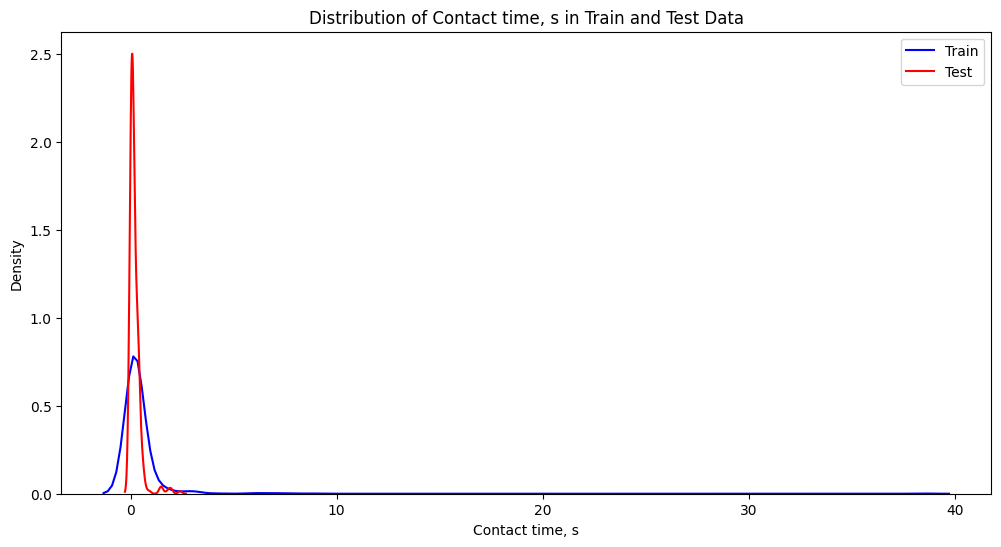

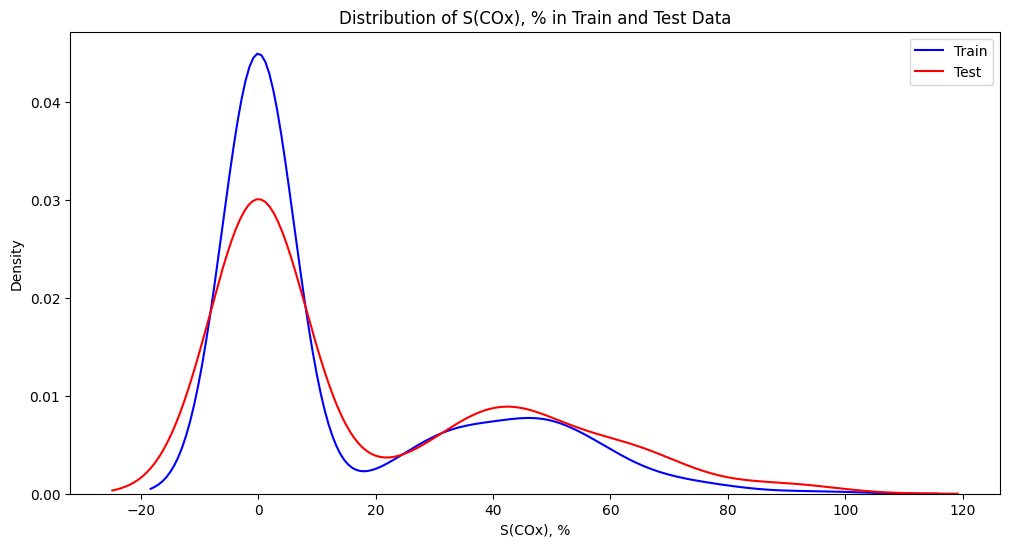

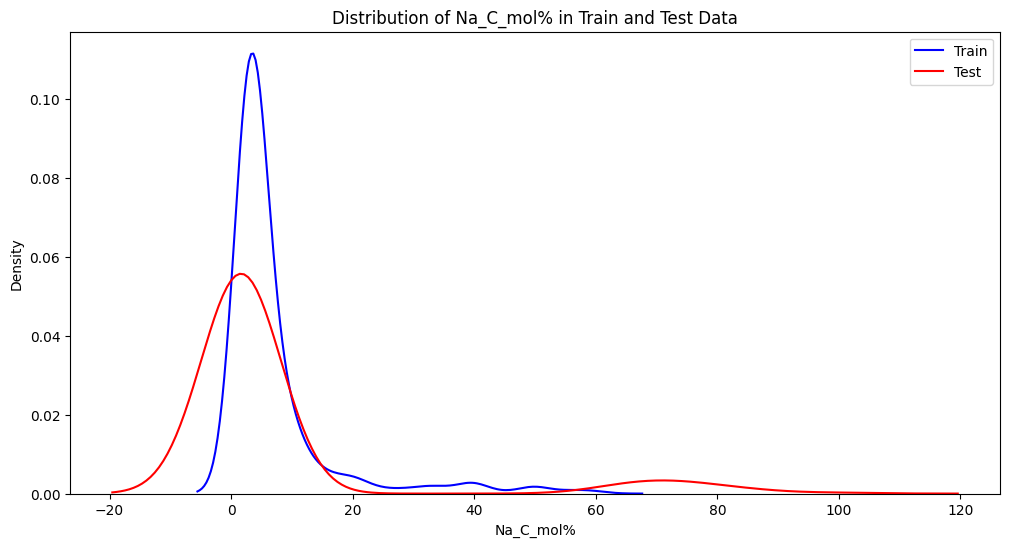

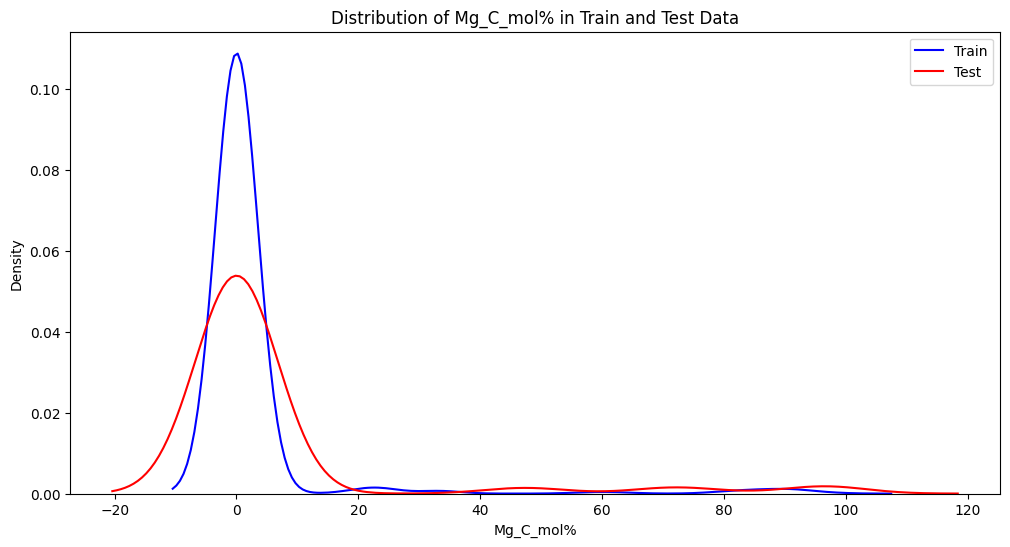

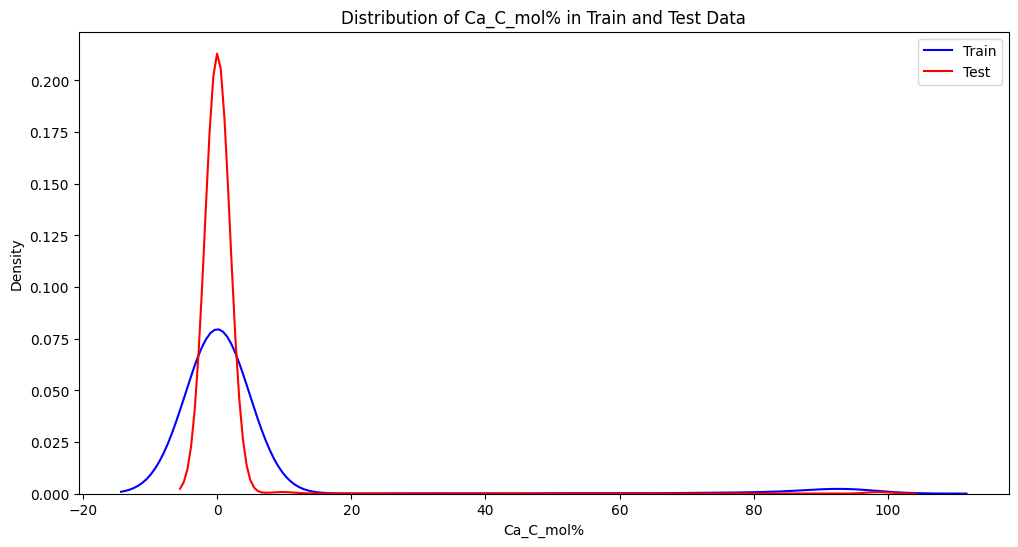

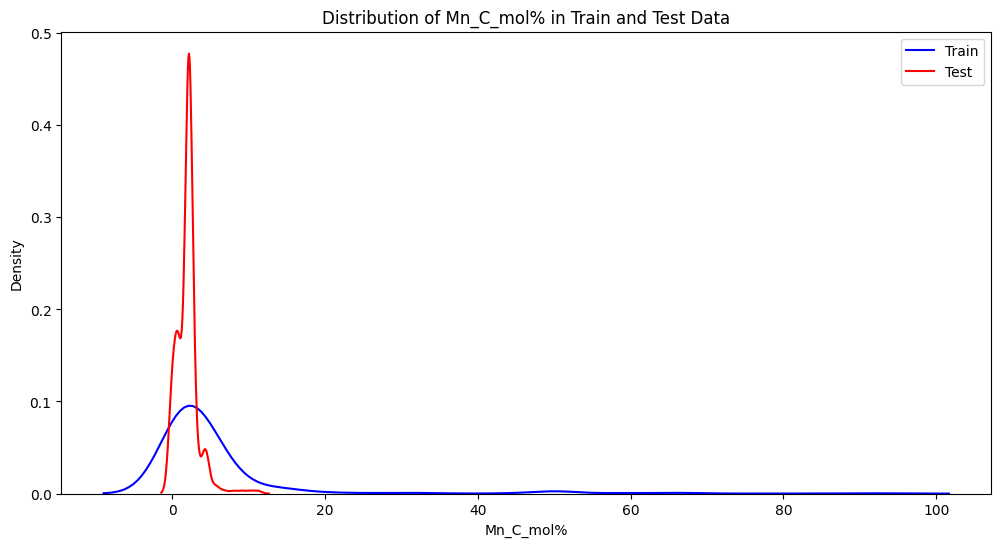

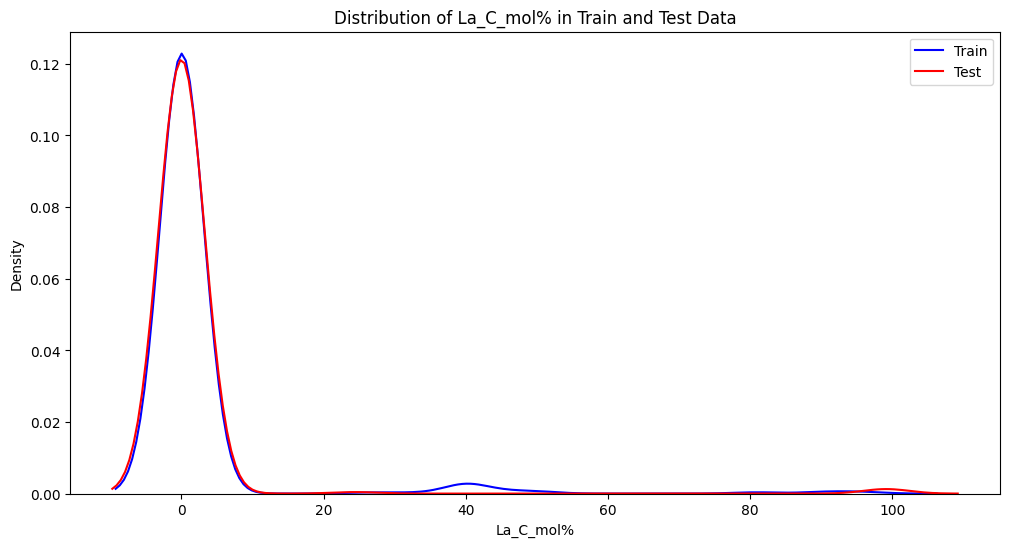

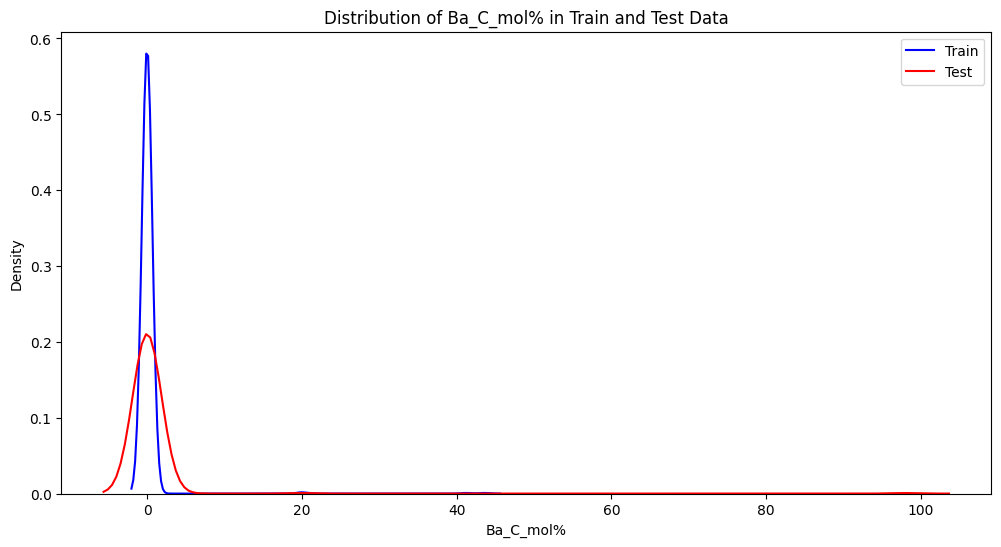

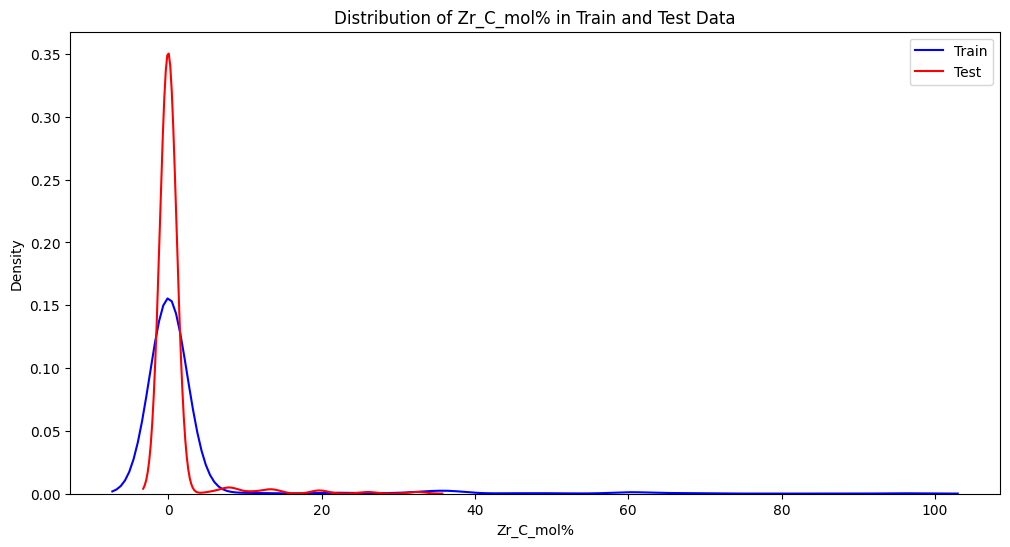

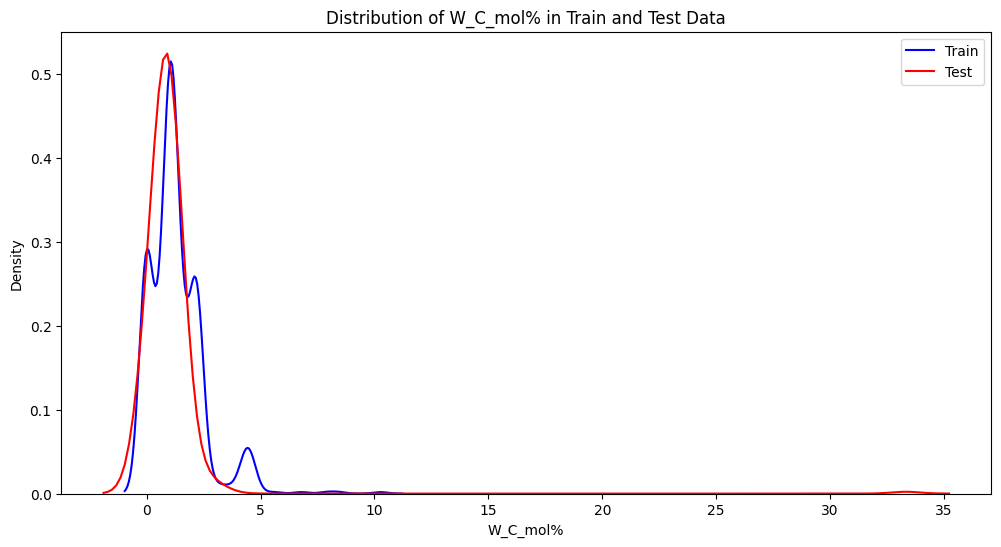

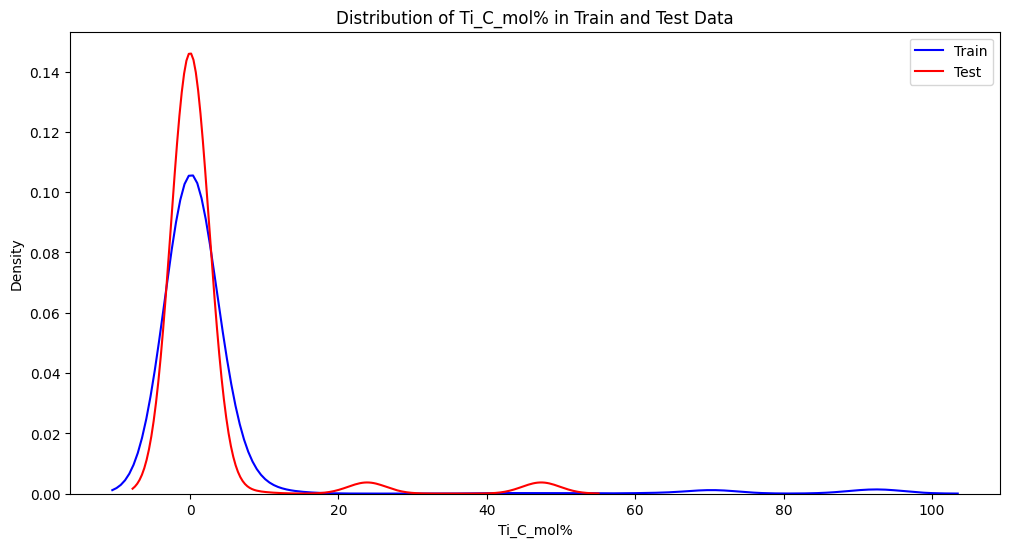

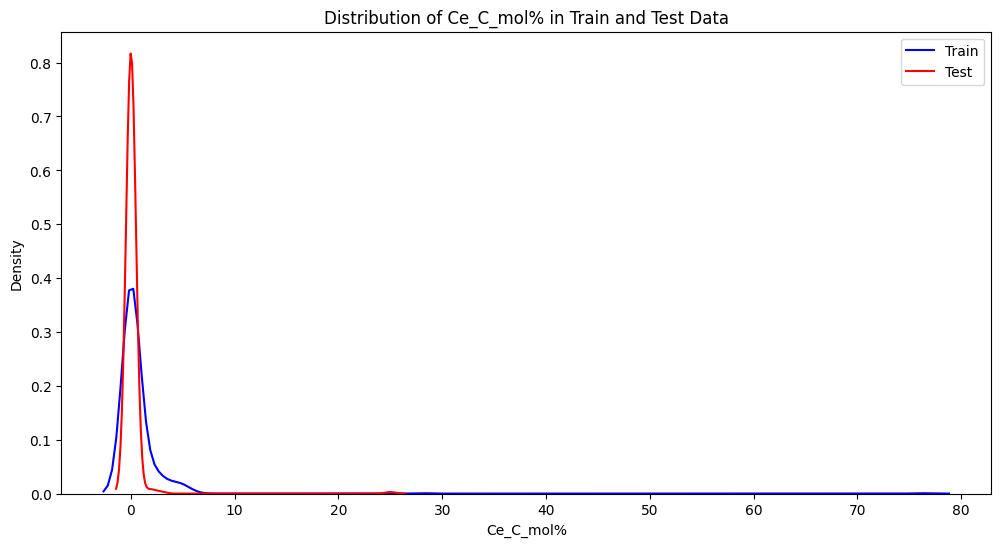

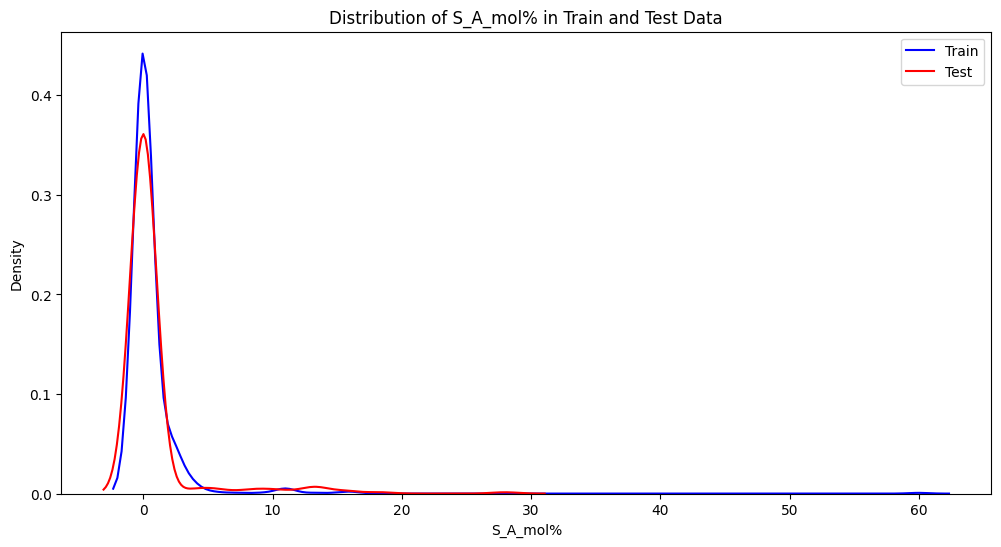

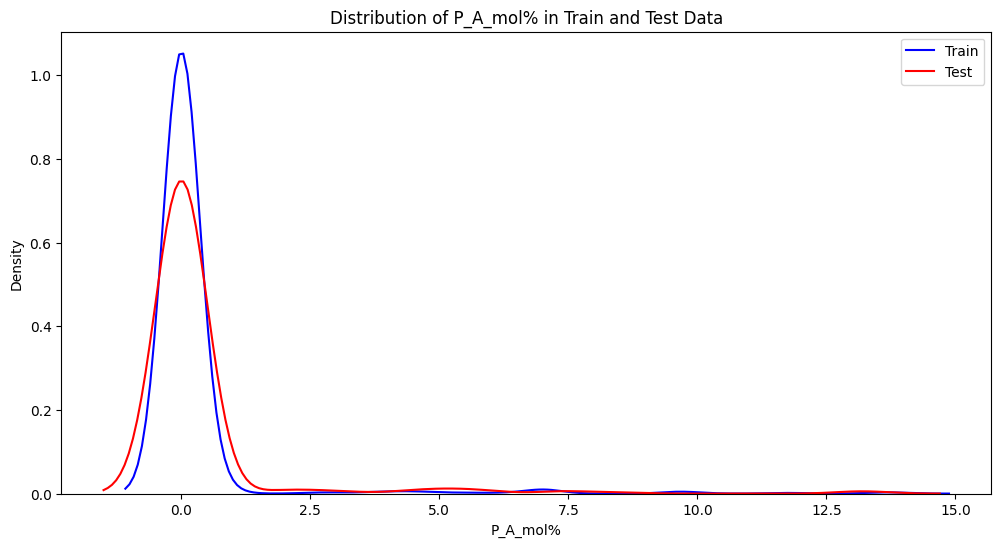

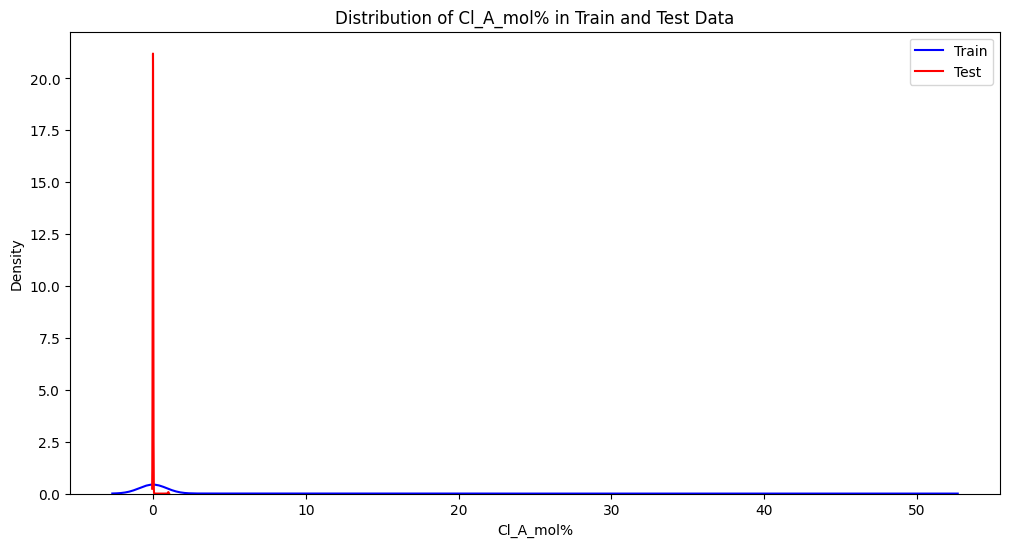

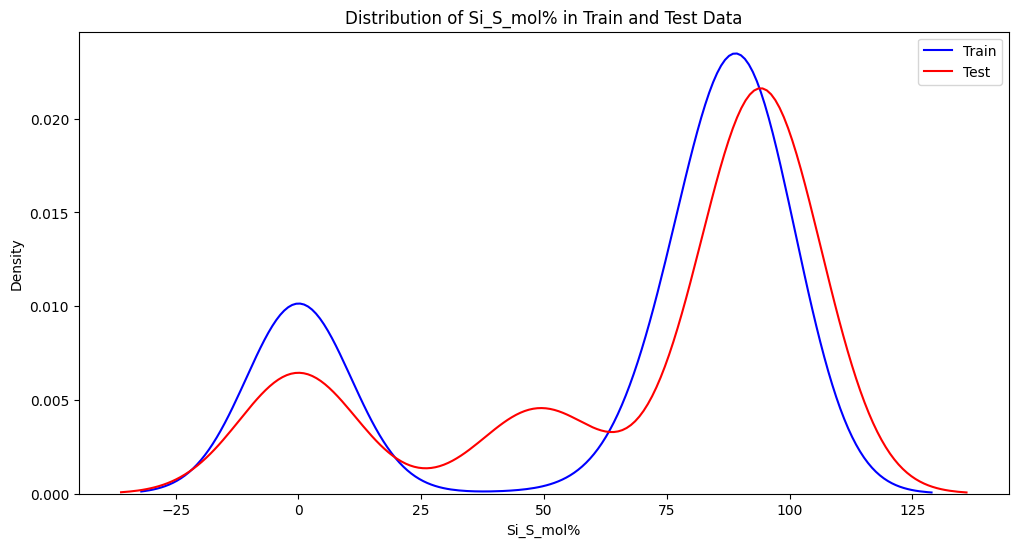

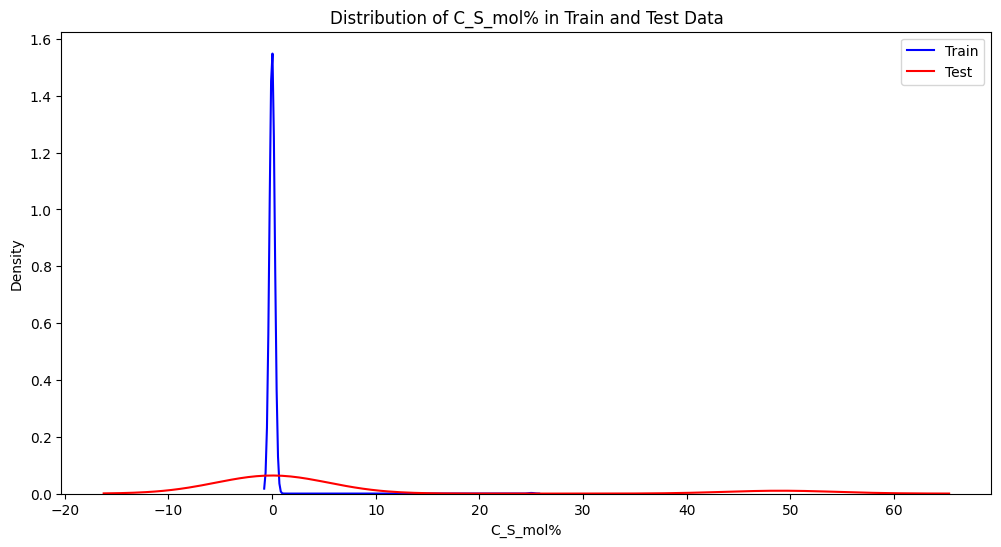

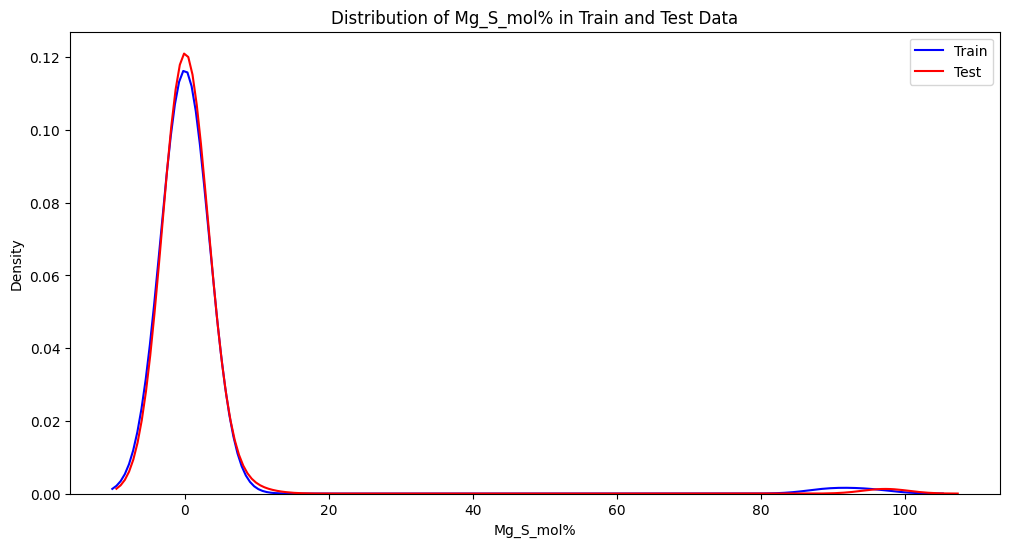

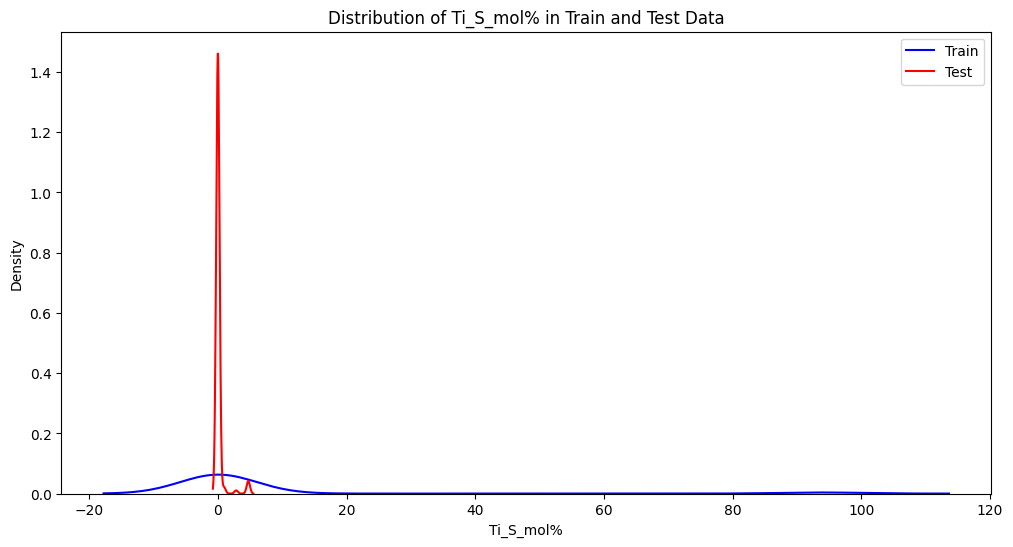

In [50]:
def plot_feature_distributions(train_data, test_data, input_columns):
    for col in input_columns:
        plt.figure(figsize=(12, 6))
        
        sns.kdeplot(train_data[col], label='Train', color='b')
        sns.kdeplot(test_data[col], label='Test', color='r')
        
        plt.title(f'Distribution of {col} in Train and Test Data')
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.legend()
        
        plt.show()

# Let's plot the feature distributions for the train and test data
plot_feature_distributions(train_data, test_data, input_columns)

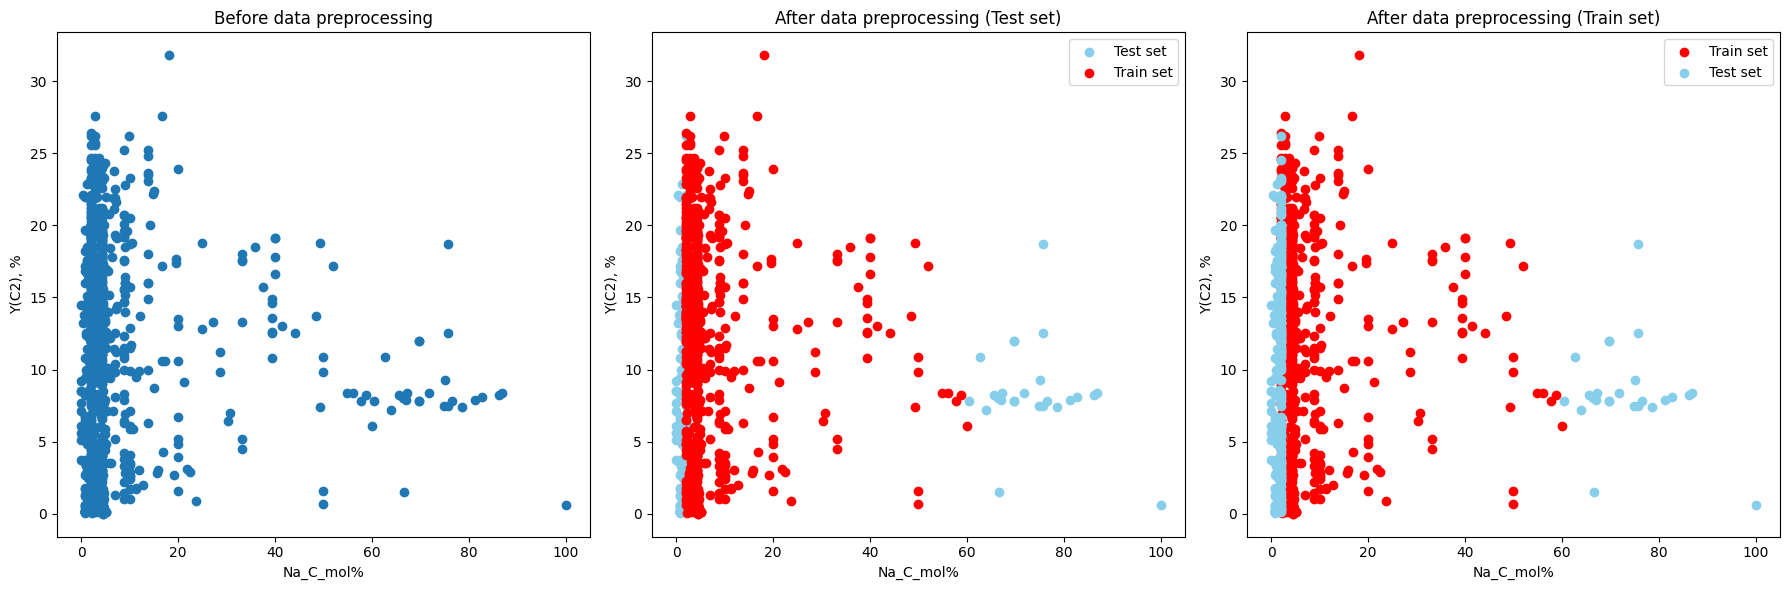

In [51]:
# Create a figure and a set of subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot before preprocessing
axs[0].scatter(filtered_Na['Na_C_mol%'], filtered_Na['Y(C2), %'])
axs[0].set_title('Before data preprocessing')
axs[0].set_xlabel('Na_C_mol%')
axs[0].set_ylabel('Y(C2), %')

# Plot after preprocessing with test set
axs[1].scatter(test_data['Na_C_mol%'], test_data['Y(C2), %'], color='skyblue', label='Test set')
axs[1].scatter(train_data['Na_C_mol%'], train_data['Y(C2), %'], color='red', label='Train set')
axs[1].set_title('After data preprocessing (Test set)')
axs[1].set_xlabel('Na_C_mol%')
axs[1].set_ylabel('Y(C2), %')
axs[1].legend()

# Plot after preprocessing with train set
axs[2].scatter(train_data['Na_C_mol%'], train_data['Y(C2), %'], color='red', label='Train set')
axs[2].scatter(test_data['Na_C_mol%'], test_data['Y(C2), %'], color='skyblue', label='Test set')
axs[2].set_title('After data preprocessing (Train set)')
axs[2].set_xlabel('Na_C_mol%')
axs[2].set_ylabel('Y(C2), %')
axs[2].legend()

# Show plots
plt.tight_layout()
plt.show()

In [52]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the StandardScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both the training and test data
Na_train_scaled = scaler.fit_transform(filtered_Na[input_columns])
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_1 = MinMaxScaler()

# Reshape the output_column to be 2D
output_scaled = scaler_1.fit_transform(filtered_Na[output_column].values.reshape(-1, 1))

# Reshape the y_train and y_test to be 2D
y_train_scaled = scaler_1.transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_1.transform(y_test.values.reshape(-1, 1))

In [53]:
print("Mean:", np.mean(y_train_scaled))
print("Standard Deviation:", np.std(y_train_scaled))
print("Min:", np.min(y_train_scaled))
print("Max:", np.max(y_train_scaled))

print("Mean:", np.mean(y_test_scaled))
print("Standard Deviation:", np.std(y_test_scaled))
print("Min:", np.min(y_test_scaled))
print("Max:", np.max(y_test_scaled))


print(y_train.describe())
print(y_test.describe())

Mean: 0.39531004560240685
Standard Deviation: 0.22032307713545826
Min: 0.0
Max: 1.0
Mean: 0.3221357262466286
Standard Deviation: 0.21448534328840865
Min: 0.000839630562552477
Max: 0.8238977097268213
count    700.000000
mean      12.571041
std        7.011218
min        0.000300
25%        7.000000
50%       13.600000
75%       18.025000
max       31.800000
Name: Y(C2), %, dtype: float64
count    293.000000
mean      10.244119
std        6.832239
min        0.027000
25%        3.700000
50%       10.400000
75%       16.500000
max       26.200000
Name: Y(C2), %, dtype: float64


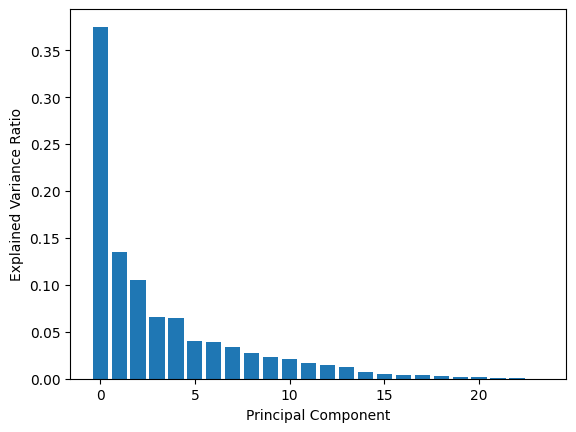

7


In [54]:
from sklearn.decomposition import PCA

# 데이터를 중앙에 맞춤 (선택 사항, PCA 내부적으로 수행됨)
# X_train_centered = X_train - np.mean(X_train, axis=0)
# X_test_centered = X_test - np.mean(X_test, axis=0)

# PCA 객체 생성
pca = PCA()

# PCA를 학습 데이터에 적합시킴
pca.fit(X_train_scaled)

# 설명된 분산의 비율을 확인
explained_var_ratio = pca.explained_variance_ratio_

# 설명된 분산의 비율을 시각화
plt.bar(range(len(explained_var_ratio)), explained_var_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

# 설명된 분산이 95% 이상이 되는 주성분 개수 선택
n_components = np.where(np.cumsum(explained_var_ratio) >= 0.80)[0][0] + 1

print(n_components)

# 선택된 주성분 개수로 PCA 다시 수행
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [55]:
from sklearn.metrics import mean_squared_error

# Initialize a dictionary to store the best parameters for each model
best_params = {}

# Linear Regression
def optimize_lr(fit_intercept):
    fit_intercept = bool(round(fit_intercept))
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_lr = BayesianOptimization(f=optimize_lr, pbounds={"fit_intercept": (0, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_lr.maximize(init_points=20, n_iter=100)
best_params['Linear Regression'] = optimizer_lr.max['params']

# Decision Tree Regressor
def optimize_dtr(max_depth, min_samples_split):
    max_depth = int(round(max_depth))
    min_samples_split = int(round(min_samples_split))
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_dtr = BayesianOptimization(f=optimize_dtr, pbounds={"max_depth": (1, 32), "min_samples_split": (2, 10)}, random_state=42, allow_duplicate_points=True)
optimizer_dtr.maximize(init_points=20, n_iter=100)
best_params['Decision Tree Regressor'] = optimizer_dtr.max['params']

# K-NN
def optimize_knn(n_neighbors, p):
    model = KNeighborsRegressor(n_neighbors=int(n_neighbors), p=p)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_knn = BayesianOptimization(f=optimize_knn, pbounds={"n_neighbors": (1, 20), "p": (1, 2)}, random_state=42, allow_duplicate_points=True)
optimizer_knn.maximize(init_points=20, n_iter=100)
best_params['K-NN'] = optimizer_knn.max['params']

# SVR
def optimize_svr(C, epsilon):
    model = SVR(C=C, epsilon=epsilon)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_svr = BayesianOptimization(f=optimize_svr, pbounds={"C": (1, 100), "epsilon": (0.01, 0.1)}, random_state=42, allow_duplicate_points=True)
optimizer_svr.maximize(init_points=20, n_iter=100)
best_params['SVR'] = optimizer_svr.max['params']

# GPR
def optimize_gpr(alpha):
    model = GaussianProcessRegressor(alpha=alpha)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_gpr = BayesianOptimization(f=optimize_gpr, pbounds={"alpha": (0.01, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_gpr.maximize(init_points=20, n_iter=100)
best_params['GaussianProcessRegressor'] = optimizer_gpr.max['params']

# RFR
def optimize_rfr(n_estimators, max_depth):
    model = RandomForestRegressor(n_estimators=int(n_estimators), max_depth=int(max_depth))
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_rfr = BayesianOptimization(f=optimize_rfr, pbounds={"n_estimators": (50, 200), "max_depth": (5, 50)}, random_state=42, allow_duplicate_points=True)
optimizer_rfr.maximize(init_points=20, n_iter=100)
best_params['RandomForestRegressor'] = optimizer_rfr.max['params']

# XGBoost
def optimize_xgb(learning_rate, n_estimators):
    model = XGBRegressor(learning_rate=learning_rate, n_estimators=int(n_estimators))
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

optimizer_xgb = BayesianOptimization(f=optimize_xgb, pbounds={"learning_rate": (0.01, 0.3), "n_estimators": (50, 200)}, random_state=42, allow_duplicate_points=True)
optimizer_xgb.maximize(init_points=20, n_iter=100)
best_params['XGBRegressor'] = optimizer_xgb.max['params']

# MLP
def optimize_mlp(alpha, learning_rate_init, hidden_layer_sizes):
    model = MLPRegressor(alpha=alpha, 
                         learning_rate_init=learning_rate_init, 
                         hidden_layer_sizes=(int(hidden_layer_sizes),),
                         activation='relu', 
                         solver='adam', 
                         max_iter=5000)  # Increased max_iter
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    return -mean_squared_error(y_train_scaled, predictions)

# Create BayesianOptimization object
optimizer_mlp = BayesianOptimization(f=optimize_mlp, 
                                    pbounds={"alpha": (0.0001, 0.1), 
                                             "learning_rate_init": (0.001, 0.1),
                                             "hidden_layer_sizes": (1, 20)},
                                    random_state=42)

# Perform Bayesian Optimization
optimizer_mlp.maximize(init_points=20, n_iter=100)
best_params['MLPRegressor'] = optimizer_mlp.max['params']

|   iter    |  target   | fit_in... |
-------------------------------------
| 1         | -0.1977   | 0.3745    |
| 2         | -0.04142  | 0.9507    |
| 3         | -0.04142  | 0.732     |
| 4         | -0.04142  | 0.5987    |
| 5         | -0.1977   | 0.156     |
| 6         | -0.1977   | 0.156     |
| 7         | -0.1977   | 0.05808   |
| 8         | -0.04142  | 0.8662    |
| 9         | -0.04142  | 0.6011    |
| 10        | -0.04142  | 0.7081    |
| 11        | -0.1977   | 0.02058   |
| 12        | -0.04142  | 0.9699    |
| 13        | -0.04142  | 0.8324    |
| 14        | -0.1977   | 0.2123    |
| 15        | -0.1977   | 0.1818    |
| 16        | -0.1977   | 0.1834    |
| 17        | -0.1977   | 0.3042    |
| 18        | -0.04142  | 0.5248    |
| 19        | -0.1977   | 0.4319    |
| 20        | -0.1977   | 0.2912    |
| 21        | -0.04142  | 1.0       |
| 22        | -0.04142  | 0.5516    |
| 23        | -0.04142  | 0.7834    |
| 24        | -0.04142  | 0.6587    |
| 25        

In [59]:
# Initialize a dictionary to store the validation MSE for each model
validation_mse = {}

# Linear Regression
best_lr_params = best_params['Linear Regression']
best_lr_params['fit_intercept'] = bool(round(best_lr_params['fit_intercept']))
lr_model = LinearRegression(**best_lr_params)
lr_model.fit(X_train_pca, y_train_scaled)
lr_predictions = lr_model.predict(X_test_pca)
lr_mse = mean_squared_error(y_test_scaled, lr_predictions)
validation_mse['Linear Regression'] = lr_mse

# K-NN
best_knn_params = best_params['K-NN']
best_knn_params['n_neighbors'] = int(round(best_knn_params['n_neighbors']))
knn_model = KNeighborsRegressor(**best_knn_params)
knn_model.fit(X_train_pca, y_train_scaled)
knn_predictions = knn_model.predict(X_test_pca)
knn_mse = mean_squared_error(y_test_scaled, knn_predictions)
validation_mse['K-NN'] = knn_mse

# SVR
best_svr_params = best_params['SVR']
svr_model = SVR(**best_svr_params)
svr_model.fit(X_train_pca, y_train_scaled)
svr_predictions = svr_model.predict(X_test_pca)
svr_mse = mean_squared_error(y_test_scaled, svr_predictions)
validation_mse['SVR'] = svr_mse

# GPR
best_gpr_params = best_params['GaussianProcessRegressor']
gpr_model = GaussianProcessRegressor(**best_gpr_params)
gpr_model.fit(X_train_pca, y_train_scaled)
gpr_predictions = gpr_model.predict(X_test_pca)
gpr_mse = mean_squared_error(y_test_scaled, gpr_predictions)
validation_mse['GaussianProcessRegressor'] = gpr_mse

# RFR
best_rfr_params = best_params['RandomForestRegressor']
best_rfr_params['max_depth'] = int(round(best_rfr_params['max_depth']))
best_rfr_params['n_estimators'] = int(round(best_rfr_params['n_estimators']))
rfr_model = RandomForestRegressor(**best_rfr_params)
rfr_model.fit(X_train_pca, y_train_scaled)
rfr_predictions = rfr_model.predict(X_test_pca)
rfr_mse = mean_squared_error(y_test_scaled, rfr_predictions)
validation_mse['RandomForestRegressor'] = rfr_mse

# XGBoost
best_xgb_params = best_params['XGBRegressor']
best_xgb_params['n_estimators'] = int(round(best_xgb_params['n_estimators']))
xgb_model = XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train_pca, y_train_scaled)
xgb_predictions = xgb_model.predict(X_test_pca)
xgb_mse = mean_squared_error(y_test_scaled, xgb_predictions)
validation_mse['XGBRegressor'] = xgb_mse

# MLP
best_mlp_params = best_params['MLPRegressor']
best_mlp_params['hidden_layer_sizes'] = int(round(best_mlp_params['hidden_layer_sizes']))
mlp_model = MLPRegressor(**best_mlp_params)
mlp_model.fit(X_train_pca, y_train_scaled)
mlp_predictions = mlp_model.predict(X_test_pca)
mlp_mse = mean_squared_error(y_test_scaled, mlp_predictions)
validation_mse['MLPRegressor'] = mlp_mse

# Initialize dictionary to hold predictions from each model for Bayesian Model Averaging
predictions_dict = {}

# Get predictions from each trained model and store in the dictionary
predictions_dict['Linear Regression'] = lr_model.predict(X_test_pca)
predictions_dict['K-NN'] = knn_model.predict(X_test_pca)
predictions_dict['SVR'] = svr_model.predict(X_test_pca)
predictions_dict['GaussianProcessRegressor'] = gpr_model.predict(X_test_pca)
predictions_dict['RandomForestRegressor'] = rfr_model.predict(X_test_pca)
predictions_dict['XGBRegressor'] = xgb_model.predict(X_test_pca)
predictions_dict['MLPRegressor'] = mlp_model.predict(X_test_pca)

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\OJH\AppData\Local\Temp\ipykernel_19244\159548533.py:43: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rfr_model.fit(X_train_pca, y_train_scaled)
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1623: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[0.041106939752695734, 0.07905353498151582, 0.06671658931291333, 0.034548569930585867, 0.02989603881434418, 0.033571213992614604, 0.037620912984938686]


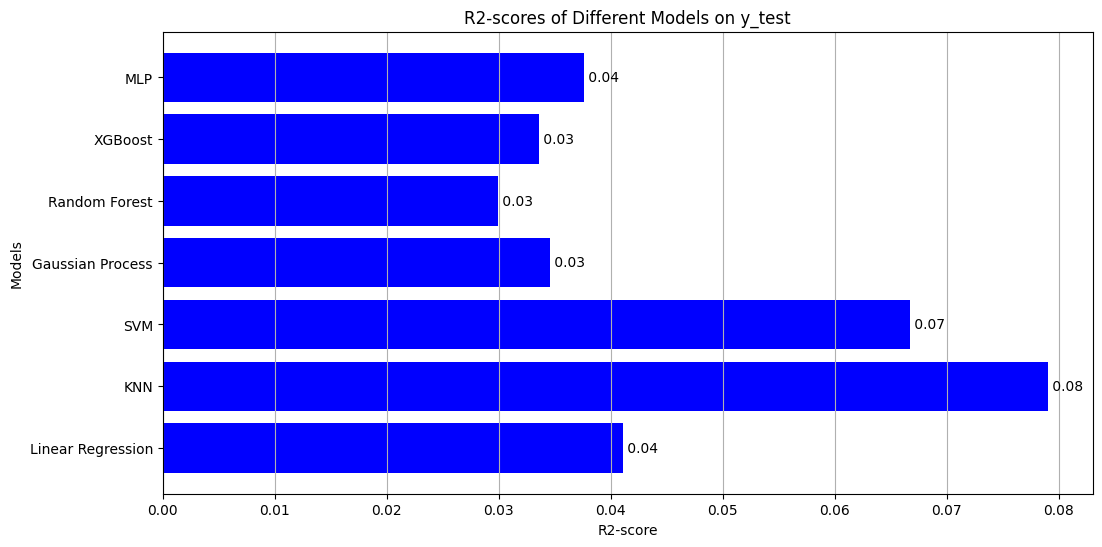

In [60]:
print([lr_mse, knn_mse, svr_mse, gpr_mse, rfr_mse, xgb_mse, mlp_mse])

mse_values = [lr_mse, knn_mse, svr_mse, gpr_mse, rfr_mse, xgb_mse, mlp_mse]
model_names = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP']


# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, mse_values, color='blue')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_test')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(mse_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [61]:
# # 특성 중요도 가져오기
# feature_importances = rfr_model.feature_importances_

# # 특성 중요도를 데이터프레임으로 변환
# importance_df = pd.DataFrame({
#     'Feature': input_columns,
#     'Importance': feature_importances
# })

# # 특성 중요도를 내림차순으로 정렬
# importance_df = importance_df.sort_values(by='Importance', ascending=False)

# # 특성 중요도 시각화
# plt.figure(figsize=(10, 8))
# plt.barh(importance_df['Feature'], importance_df['Importance'], align='center')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.show()

ValueError: All arrays must be of the same length

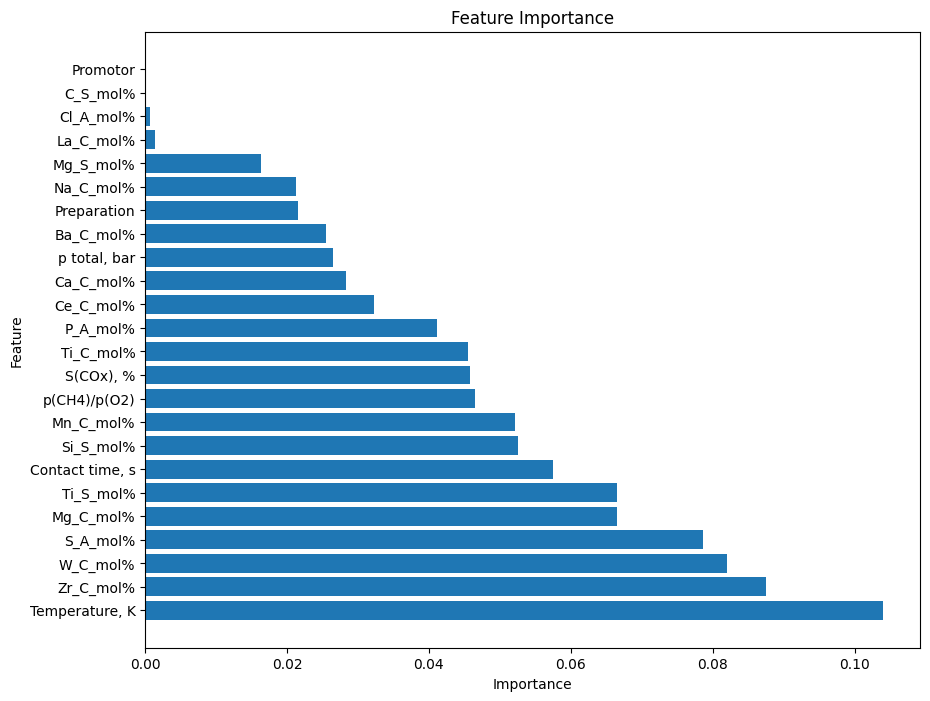

In [ ]:
# # 특성 중요도 가져오기
# feature_importances = xgb_model.feature_importances_

# # 특성 중요도를 데이터프레임으로 변환
# importance_df = pd.DataFrame({
#     'Feature': input_columns,
#     'Importance': feature_importances
# })

# # 특성 중요도를 내림차순으로 정렬
# importance_df = importance_df.sort_values(by='Importance', ascending=False)

# # 특성 중요도 시각화
# plt.figure(figsize=(10, 8))
# plt.barh(importance_df['Feature'], importance_df['Importance'], align='center')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.show()

In [62]:
from sklearn.ensemble import VotingRegressor

# Initialize the models with best parameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
mlp_model = MLPRegressor(**best_params['MLPRegressor'])

# Create a VotingRegressor instance
voting_reg = VotingRegressor(estimators=[
    ('lr', lr_model), 
    ('knn', knn_model), 
    ('svr', svr_model),
    ('gpr', gpr_model), 
    ('rfr', rfr_model), 
    ('xgb', xgb_model),
    ('mlp', mlp_model)
])

# Fit the ensemble model
voting_reg.fit(X_train_pca, y_train_scaled)

# Make predictions on validation set
voting_predictions = voting_reg.predict(X_test_pca)

# Calculate the MSE
voting_mse = mean_squared_error(y_test_scaled, voting_predictions)

# Add to the validation MSE dictionary
validation_mse['VotingRegressor'] = voting_mse

print(f"Voting Regressor MSE: {voting_mse}")

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\ensemble\_voting.py:597: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Voting Regressor MSE: 0.027882779380596863


In [63]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
mlp_model = MLPRegressor(**best_params['MLPRegressor'])

# Initialize the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model),
        ('svr', svr_model),
        ('gpr', gpr_model),
        ('rfr', rfr_model),
        ('xgb', xgb_model),
        ('mlp', mlp_model)
    ],
    final_estimator=LinearRegression()
)

# Fit the ensemble model
stacking_regressor.fit(X_train_pca, y_train_scaled)

# Make predictions on the validation set
stacking_predictions = stacking_regressor.predict(X_test_pca)

# Calculate the MSE
stacking_mse = mean_squared_error(y_test_scaled, stacking_predictions)

print(f"Stacking Regressor MSE: {stacking_mse}")

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\ensemble\_stacking.py:957: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Stacking Regressor MSE: 0.04276203804047039


[0.041106939752695734, 0.07905353498151582, 0.06671658931291333, 0.034548569930585867, 0.02989603881434418, 0.033571213992614604, 0.037620912984938686, 0.027882779380596863, 0.04276203804047039]


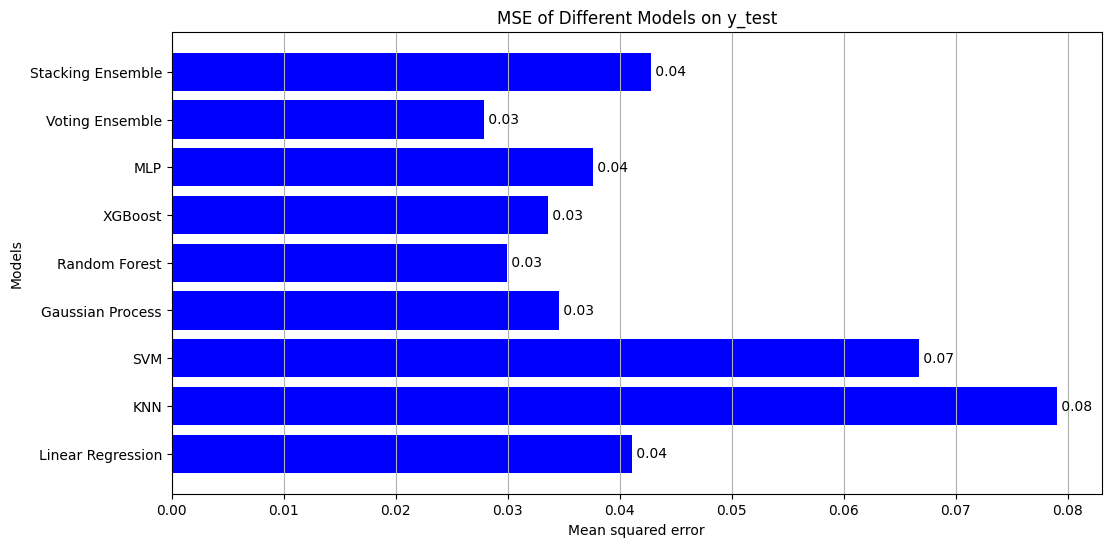

In [64]:
print([lr_mse, knn_mse, svr_mse, gpr_mse, rfr_mse, xgb_mse, mlp_mse, voting_mse, stacking_mse])

mse_values = [lr_mse, knn_mse, svr_mse, gpr_mse, rfr_mse, xgb_mse, mlp_mse, voting_mse, stacking_mse]
model_names = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']


# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, mse_values, color='blue')
plt.xlabel('Mean squared error')
plt.ylabel('Models')
plt.title('MSE of Different Models on y_test')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(mse_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [66]:
lr_predictions_original = scaler_1.inverse_transform(lr_predictions.reshape(-1, 1))
knn_predictions_original = scaler_1.inverse_transform(knn_predictions.reshape(-1, 1))
svr_predictions_original = scaler_1.inverse_transform(svr_predictions.reshape(-1, 1))
gpr_predictions_original = scaler_1.inverse_transform(gpr_predictions.reshape(-1, 1))
rfr_predictions_original = scaler_1.inverse_transform(rfr_predictions.reshape(-1, 1))
xgb_predictions_original = scaler_1.inverse_transform(xgb_predictions.reshape(-1, 1))
mlp_predictions_original = scaler_1.inverse_transform(mlp_predictions.reshape(-1, 1))
voting_predictions_original = scaler_1.inverse_transform(voting_predictions.reshape(-1, 1))
stacking_predictions_original = scaler_1.inverse_transform(stacking_predictions.reshape(-1, 1))

results_df = pd.DataFrame({
    'y_test_original': y_test.ravel(),
    'lr_predictions_original': lr_predictions_original.ravel(),
    'knn_predictions_original': knn_predictions_original.ravel(),
    'svr_predictions_original': svr_predictions_original.ravel(),
    'gpr_predictions_original': gpr_predictions_original.ravel(),
    'rfr_predictions_original': rfr_predictions_original.ravel(),
    'xgb_predictions_original': xgb_predictions_original.ravel(),
    'mlp_predictions_original': mlp_predictions_original.ravel(),
    'voting_predictions_original': voting_predictions_original.ravel(),
    'stacking_predictions_original': stacking_predictions_original.ravel()
})

results_df.to_csv('model_predictions.csv', index=False)

results_df

,y_test_original,lr_predictions_original,knn_predictions_original,svr_predictions_original,gpr_predictions_original,rfr_predictions_original,xgb_predictions_original,mlp_predictions_original,voting_predictions_original,stacking_predictions_original
0,15.1,13.356830,17.5,1.727664,13.097430,13.456461,15.591306,14.261603,12.392707,13.531191
1,12.5,8.451094,13.3,12.166917,12.133108,12.258989,12.307424,11.290711,11.633226,13.150049
2,0.6,12.296150,0.7,0.565250,8.371112,11.699813,12.674245,10.417842,8.442625,12.413960
3,13.8,6.605367,19.2,11.722030,12.964480,6.516854,10.448024,14.386920,10.457996,11.495377
4,2.8,15.879949,4.4,11.141942,12.537464,12.810112,14.113544,13.858255,12.359344,13.353654
...,...,...,...,...,...,...,...,...,...,...
288,18.7,13.842887,18.7,17.589301,16.589775,18.919663,19.381138,17.667486,17.363743,14.964298
289,16.7,13.998349,16.7,18.566773,16.961618,16.555618,16.707127,17.605211,16.404476,14.583146
290,13.6,13.710546,13.6,15.128863,15.753421,13.341573,11.990718,16.662929,14.082828,13.933687
291,14.0,13.532224,14.0,12.769616,14.845863,13.478090,13.177078,15.862718,13.707902,13.564617


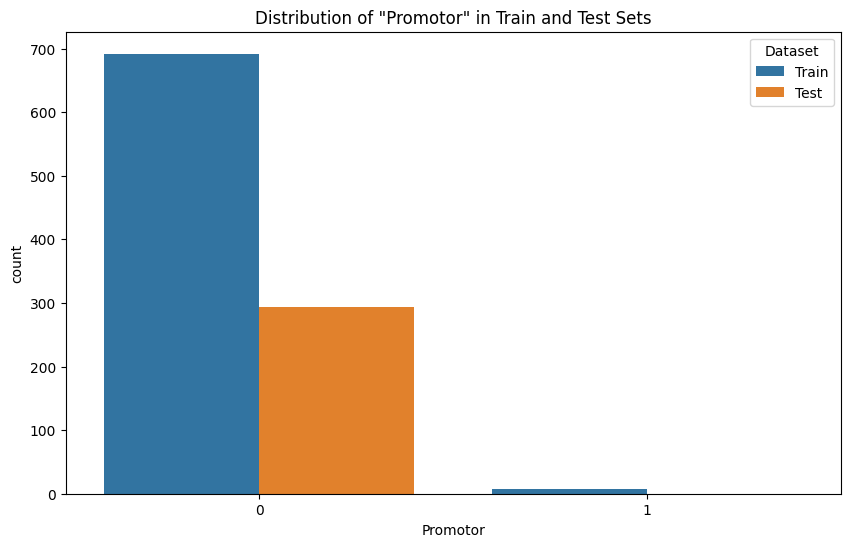

In [ ]:
# Create DataFrame for easy plotting
df_train = pd.DataFrame({'Promotor': X_train['Promotor'], 'Dataset': 'Train'})
df_test = pd.DataFrame({'Promotor': X_test['Promotor'], 'Dataset': 'Test'})
df = pd.concat([df_train, df_test])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Promotor', hue='Dataset')
plt.title('Distribution of "Promotor" in Train and Test Sets')
plt.show()

In [ ]:
from patsy import dmatrix

print(X_train[col].describe())
print(X_test[col].describe())

print(len(np.unique(X_train[col])))
print(len(np.unique(X_test[col])))

# Initialize an empty array for ensemble predictions
ensemble_predictions = np.zeros(len(y_test))

# Number of ensemble models
n_models = 1000

# Loop through each feature and fit a MARS model
for col in input_columns:
    # Create design matrices for the train and test sets for the current feature
    design_matrix_train = dmatrix("cr(x, df=3)", {"x": X_train[col]})
    design_matrix_test = dmatrix("cr(x, df=3)", {"x": X_test[col]})
    
    # Initialize temporary predictions for the ensemble
    temp_predictions = np.zeros(len(y_test))
    
    # Fit n_models number of MARS models and accumulate their predictions
    for _ in range(n_models):
        model = LinearRegression()
        model.fit(design_matrix_train, y_train)
        predictions = model.predict(design_matrix_test)
        temp_predictions += predictions

    # Average the predictions for the current feature
    temp_predictions /= n_models
    
    # Add the averaged predictions to the ensemble predictions
    ensemble_predictions += temp_predictions

# Average the ensemble predictions across all features
ensemble_predictions /= len(input_columns)

# Calculate the ensemble MSE
ensemble_mse = mean_squared_error(y_test, ensemble_predictions)

print(f"Ensemble MARS MSE: {ensemble_mse}")

count    700.000000
mean       0.011429
std        0.106368
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: Promotor, dtype: float64
count    293.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Promotor, dtype: float64
2
1


ValueError: Unable to compute n_inner_knots(=1) + 2 distinct knots: 1 data value(s) found between lower_bound(=0) and upper_bound(=0).

In [ ]:
import pymc as pm
import aesara.tensor as at
import aesara

# Check the length of y_val
print("Length of y_val:", len(y_test))

# Check the length of one set of predictions (assuming all have the same length)
print("Length of a set of predictions:", len(predictions_dict['Linear Regression']))

# Actual target values: Replace these with your actual target values
y_test = y_test

# Number of models
num_models = len(predictions_dict)

# Initialize Bayesian Model
with pm.Model() as model:
    # Prior for each model's weight
    w = pm.Dirichlet('w', a=np.ones(num_models))

    # Expected value calculation based on model weights
    mu = pm.math.dot(w, np.array([predictions_dict[model_name] for model_name in predictions_dict.keys()]))

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sd=1, observed=y_test)

    # Run MCMC
    trace = pm.sample(2000, tune=1000)

# Extract trace for the model weights
trace_w = trace['w']

# Calculate Bayesian Model Average
bma_prediction = np.dot(trace_w.mean(axis=0), [predictions_dict[model_name] for model_name in predictions_dict.keys()])

Length of y_val: 293
Length of a set of predictions: 293


TypeError: RandomVariable.make_node() got an unexpected keyword argument 'sd'

In [ ]:

# Initialize an empty list to store MSE values
mse_values = []

# Initialize an empty list to store different percentage thresholds
thresholds = [0.0, 0.05, 0.1, 0.15]

for threshold in thresholds:
    # Identify columns where non-zero (non-missing) data is less than the threshold
    total_rows = len(filtered_Na)
    columns_to_remove = []
    rows_to_remove = set()

    for col in filtered_Na.columns:
        non_zero_count = len(filtered_Na[filtered_Na[col] != 0])
        if non_zero_count / total_rows < threshold:
            columns_to_remove.append(col)
            # Collect row indices where data in this column is not missing (not zero)
            rows_to_remove.update(filtered_Na.index[filtered_Na[col] != 0].tolist())

    # Remove the identified columns and rows
    reduced_Na = filtered_Na.drop(columns=columns_to_remove)
    reduced_Na.drop(index=list(rows_to_remove), inplace=True)

    # Prepare the data for ML models
    column_names = reduced_Na.columns.tolist()
    input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
    output_column = 'Y(C2), %'

    if output_column in reduced_Na.columns:
        X = reduced_Na[input_columns]
        y = reduced_Na[output_column]

        # Split the data into training and validation sets (80%, 20%)
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

        # Initialize models with fixed hyperparameters
        models = {
            'Linear Regression': LinearRegression(),
            'K-NN': KNeighborsRegressor(),
            'SVR': SVR(),
            'GPR': GaussianProcessRegressor(),
            'RFR': RandomForestRegressor(),
            'XGBoost': XGBRegressor(),
            'MLP Regressor': MLPRegressor(max_iter=500)
        }

        # Compute MSE for each model
        model_mse = {}
        for name, model in models.items():
            model.fit(X_train, y_train)
            predictions = model.predict(X_val)
            mse = mean_squared_error(y_val, predictions)
            model_mse[name] = mse

        mse_values.append(model_mse)

# Plotting
labels = list(models.keys())
linear_reg_mse = [x['Linear Regression'] for x in mse_values]
knn_mse = [x['K-NN'] for x in mse_values]
svr_mse = [x['SVR'] for x in mse_values]
gpr_mse = [x['GPR'] for x in mse_values]
rfr_mse = [x['RFR'] for x in mse_values]
xgb_mse = [x['XGBoost'] for x in mse_values]
mlp_mse = [x['MLP Regressor'] for x in mse_values]

x = np.arange(len(thresholds))
width = 0.1

fig, ax = plt.subplots(figsize=(15, 8))

rects1 = ax.bar(x - 3*width/2, linear_reg_mse, width, label='Linear Regression')
rects2 = ax.bar(x - width/2, knn_mse, width, label='K-NN')
rects3 = ax.bar(x + width/2, svr_mse, width, label='SVR')
rects4 = ax.bar(x + 3*width/2, gpr_mse, width, label='GPR')
rects5 = ax.bar(x + 5*width/2, rfr_mse, width, label='RFR')
rects6 = ax.bar(x + 7*width/2, xgb_mse, width, label='XGBoost')
rects7 = ax.bar(x + 9*width/2, mlp_mse, width, label='MLP Regressor')

ax.set_ylabel('MSE')
ax.set_title('MSE values by different models and thresholds')
ax.set_xticks(x)
ax.set_xticklabels([str(th*100) + "%" for th in thresholds])
ax.legend()

fig.tight_layout()
plt.show()